## Import libraries

In [1]:
# Setup and Imports
from pathlib import Path
import os, sys

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))
os.chdir(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown
import warnings
warnings.filterwarnings('ignore')

from fmu2ml.analysis.comparative import (
    CoolingModelComparator,
    SystemProfiler,
    MetricsCalculator,
    CDUResponseAnalyzer,
    SensitivityAnalyzer,
    DynamicResponseAnalyzer,
    TransferFunctionAnalyzer,
    OperatingRegimeAnalyzer,
    PhysicsConstraintValidator,
    CDUComparativeAnalysis,
    AnalysisConfig,
    run_analysis
)

sns.set_style("whitegrid")
%matplotlib inline

print("✓ Imports complete")

✓ Imports complete


In [2]:
#  Configuration
# Systems to compare
SYSTEMS = ['marconi100', 'summit','lassen']  # Add more systems as needed

# Data paths (if using existing data)
DATA_PATHS = {
    'marconi100': '../marconi/data/chunk_0/fmu_output_24.0hrs_operational.parquet',
    'summit': '../summit/data/chunk_0/fmu_output_1.0hrs_operational.parquet',
    'lassen' : '../lassen/data/chunk_0/fmu_output_1.0hrs_operational.parquet'
}

# Output directories
OUTPUT_DIR_BASE = f'../results/comparative_analysis'
SYSTEM_COMPARISON_DIR = f'{OUTPUT_DIR_BASE}/system_comparison'
CDU_LEVEL_DIR = f'{OUTPUT_DIR_BASE}/cdu_level'
PHYSICS_VALIDATION_DIR = f'{OUTPUT_DIR_BASE}/physics_validation'

# Create output directories
for dir_path in [SYSTEM_COMPARISON_DIR, CDU_LEVEL_DIR, PHYSICS_VALIDATION_DIR]:
    os.makedirs(dir_path, exist_ok=True)

# Analysis parameters
SAMPLE_SIZE = 3600 # None for full dataset
N_WORKERS = 48
USE_EXISTING_DATA = True  # False to generate new data
N_GENERATED_SAMPLES = 500  # For data generation

# CDU-level analysis settings
N_REPRESENTATIVE_CDUS = 5  # Number of CDUs to analyze in detail
SPECIFIC_CDU_IDS = None  # [1, 10, 20] or None for auto-selection

print(f"Systems to compare: {SYSTEMS}")
print(f"Output directory: {OUTPUT_DIR_BASE}")
print(f"Using existing data: {USE_EXISTING_DATA}")
print(f"Workers: {N_WORKERS}")

Systems to compare: ['marconi100', 'summit', 'lassen']
Output directory: ../results/comparative_analysis
Using existing data: True
Workers: 48


In [3]:
# Initialize System-Level Comparator
print("="*80)
print("SYSTEM-LEVEL COMPARISON")
print("="*80)

comparator = CoolingModelComparator(
    system_names=SYSTEMS,
    n_workers=N_WORKERS
)

print(f"Initialized comparator for {len(SYSTEMS)} systems")

2026-01-21 11:52:12 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO - SystemProfiler initialized for: marconi100
2026-01-21 11:52:12 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO -   - CDUs: 49
2026-01-21 11:52:12 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO -   - Cooling Efficiency: 0.945
2026-01-21 11:52:12 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO - SystemProfiler initialized for: summit
2026-01-21 11:52:12 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO -   - CDUs: 257
2026-01-21 11:52:12 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO -   - Cooling Efficiency: 0.945
2026-01-21 11:52:12 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO - SystemProfiler initialized for: lassen
2026-01-21 11:52:12 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO -   - CDUs: 257
2026-01-21 11:52:12 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO -   - Cooling E

SYSTEM-LEVEL COMPARISON
Initialized comparator for 3 systems


In [4]:
#  Load or Generate Data
if USE_EXISTING_DATA:
    print("\nLoading existing data...")
    comparator.load_data(DATA_PATHS, sample_size=SAMPLE_SIZE)
else:
    print("\nGenerating new simulation data...")
    comparator.generate_data(
        n_samples=N_GENERATED_SAMPLES,
        input_ranges={
            'Q_flow': (12.0, 40.0),
            'T_Air': (288.15, 308.15),
            'T_ext': (283.15, 313.15)
        }
    )

print("✓ Data ready for analysis")

2026-01-21 11:52:14 - fmu2ml.analysis.comparative.analyzers.cooling_model_comparator - INFO - Loading data for all systems...
2026-01-21 11:52:14 - fmu2ml.analysis.comparative.analyzers.cooling_model_comparator - INFO - Loading data for marconi100 from ../marconi/data/chunk_0/fmu_output_24.0hrs_operational.parquet



Loading existing data...


2026-01-21 11:52:15 - fmu2ml.analysis.comparative.analyzers.cooling_model_comparator - INFO -   Loaded 3600 samples for marconi100
2026-01-21 11:52:15 - fmu2ml.analysis.comparative.analyzers.cooling_model_comparator - INFO - Loading data for summit from ../summit/data/chunk_0/fmu_output_1.0hrs_operational.parquet
2026-01-21 11:52:21 - fmu2ml.analysis.comparative.analyzers.cooling_model_comparator - INFO -   Loaded 3600 samples for summit
2026-01-21 11:52:21 - fmu2ml.analysis.comparative.analyzers.cooling_model_comparator - INFO - Loading data for lassen from ../lassen/data/chunk_0/fmu_output_1.0hrs_operational.parquet
2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.cooling_model_comparator - INFO -   Loaded 3600 samples for lassen


✓ Data ready for analysis


In [5]:
# System Profiles
print("\n" + "="*80)
print("SYSTEM PROFILES")
print("="*80)

for system_name in SYSTEMS:
    profiler = SystemProfiler(system_name)
    display(Markdown(f"### {system_name.upper()}"))
    print(profiler.summarize())
    print()

2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO - SystemProfiler initialized for: marconi100
2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO -   - CDUs: 49
2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO -   - Cooling Efficiency: 0.945



SYSTEM PROFILES


### MARCONI100

2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO - SystemProfiler initialized for: summit
2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO -   - CDUs: 257
2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO -   - Cooling Efficiency: 0.945


System Profile: MARCONI100

Location: IT

Infrastructure:
  - CDUs: 49
  - Racks per CDU: 1
  - Total Racks: 49
  - Nodes per Rack: 20
  - Total Nodes: 980

Compute Capacity:
  - CPUs per Node: 2
  - GPUs per Node: 4
  - Total CPUs: 1960
  - Total GPUs: 3920
  - Peak Performance: 31.35 PFLOPS

Cooling:
  - Efficiency: 0.945
  - Wet Bulb Temp: 290.00 K

Power Characteristics:
  - Min Node Power: 12.37 kW
  - Max Node Power: 39.56 kW
  - Max Rack Power: 791.10 kW



### SUMMIT

2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO - SystemProfiler initialized for: lassen
2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO -   - CDUs: 257
2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.system_profiler - INFO -   - Cooling Efficiency: 0.945


System Profile: SUMMIT

Location: US

Infrastructure:
  - CDUs: 257
  - Racks per CDU: 1
  - Total Racks: 257
  - Nodes per Rack: 18
  - Total Nodes: 4626

Compute Capacity:
  - CPUs per Node: 2
  - GPUs per Node: 6
  - Total CPUs: 9252
  - Total GPUs: 27756
  - Peak Performance: 220.53 PFLOPS

Cooling:
  - Efficiency: 0.945
  - Wet Bulb Temp: 290.00 K

Power Characteristics:
  - Min Node Power: 13.82 kW
  - Max Node Power: 49.32 kW
  - Max Rack Power: 887.82 kW



### LASSEN

System Profile: LASSEN

Location: US

Infrastructure:
  - CDUs: 257
  - Racks per CDU: 1
  - Total Racks: 257
  - Nodes per Rack: 18
  - Total Nodes: 4626

Compute Capacity:
  - CPUs per Node: 2
  - GPUs per Node: 4
  - Total CPUs: 9252
  - Total GPUs: 18504
  - Peak Performance: 148.00 PFLOPS

Cooling:
  - Efficiency: 0.945
  - Wet Bulb Temp: 290.00 K

Power Characteristics:
  - Min Node Power: 0.00 kW
  - Max Node Power: 0.00 kW
  - Max Rack Power: 0.00 kW



In [6]:
# Compute System-Level Metrics
print("="*80)
print("Computing comprehensive metrics...")
print("="*80)

system_metrics = comparator.compute_metrics(time_step=1.0)

# Display summary
for system_name, metrics in system_metrics.items():
    print(f"\n{system_name.upper()} Summary:")
    print(f"  CDUs: {metrics['system_info']['num_cdus']}")
    print(f"  Cooling Efficiency: {metrics['system_info']['cooling_efficiency']}")
    if 'efficiency' in metrics:
        print(f"  Mean CDUP Power: {metrics['efficiency'].get('mean_cdup_power_kw', 'N/A'):.2f} kW")
        print(f"  Cooling Power Ratio: {metrics['efficiency'].get('cooling_power_ratio', 'N/A'):.4f}")

2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.cooling_model_comparator - INFO - Computing metrics for all systems...
2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.cooling_model_comparator - INFO - Computing metrics for marconi100...
2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.cooling_model_comparator - INFO - Computing metrics for summit...
2026-01-21 11:52:22 - fmu2ml.analysis.comparative.analyzers.cooling_model_comparator - INFO - Computing metrics for lassen...


Computing comprehensive metrics...

MARCONI100 Summary:
  CDUs: 49
  Cooling Efficiency: 0.945
  Mean CDUP Power: 200.56 kW
  Cooling Power Ratio: 0.0002

SUMMIT Summary:
  CDUs: 257
  Cooling Efficiency: 0.945
  Mean CDUP Power: 1066.88 kW
  Cooling Power Ratio: 0.0001

LASSEN Summary:
  CDUs: 257
  Cooling Efficiency: 0.945
  Mean CDUP Power: 182.10 kW
  Cooling Power Ratio: 0.0001


In [7]:
# Efficiency Comparison
print("\n" + "="*80)
print("EFFICIENCY COMPARISON")
print("="*80)

efficiency_df = comparator.compare_efficiency()
display(efficiency_df)

# Save
efficiency_df.to_csv(f'{SYSTEM_COMPARISON_DIR}/efficiency_comparison.csv', index=False)
print(f"✓ Saved to {SYSTEM_COMPARISON_DIR}/efficiency_comparison.csv")


EFFICIENCY COMPARISON


,system,num_cdus,cooling_efficiency,mean_cdup_power_kw,max_cdup_power_kw,cdup_power_std,mean_heat_load_kw,max_heat_load_kw,cooling_power_ratio,cdup_power_per_cdu_kw,heat_load_per_cdu_kw
0,marconi100,49,0.945,200.562379,201.374201,0.481116,1.241263e+06,1.375477e+06,0.000162,4.093110,25331.890665
1,summit,257,0.945,1066.878414,1067.306842,0.473492,8.010970e+06,8.286766e+06,0.000133,4.151278,31171.090042
2,lassen,257,0.945,182.104532,182.448275,0.254970,2.366519e+06,2.711552e+06,0.000077,0.708578,9208.246658


✓ Saved to ../results/comparative_analysis/system_comparison/efficiency_comparison.csv


In [8]:
# Thermal Performance Comparison
print("\n" + "="*80)
print("THERMAL PERFORMANCE COMPARISON")
print("="*80)

thermal_df = comparator.compare_thermal_performance()
display(thermal_df)

# Save
thermal_df.to_csv(f'{SYSTEM_COMPARISON_DIR}/thermal_comparison.csv', index=False)
print(f"✓ Saved to {SYSTEM_COMPARISON_DIR}/thermal_comparison.csv")


THERMAL PERFORMANCE COMPARISON


,system,num_cdus,mean_rack_return_temp_c,max_rack_return_temp_c,rack_return_temp_std,mean_rack_supply_temp_c,rack_supply_temp_range,mean_delta_t_c,max_delta_t_c,mean_facility_return_temp_c
0,marconi100,49,31.061500,40.482928,3.194927,30.805563,23.528190,0.255937,0.278350,21.096534
1,summit,257,43.847145,48.617503,0.800974,43.542558,8.219170,0.304587,0.311777,32.578046
2,lassen,257,41.355875,52.612192,1.833169,40.818883,17.480475,0.536992,0.597445,20.780496


✓ Saved to ../results/comparative_analysis/system_comparison/thermal_comparison.csv


In [9]:
# Flow Characteristics Comparison
print("\n" + "="*80)
print("FLOW CHARACTERISTICS COMPARISON")
print("="*80)

flow_df = comparator.compare_flow_characteristics()
display(flow_df)

# Save
flow_df.to_csv(f'{SYSTEM_COMPARISON_DIR}/flow_comparison.csv', index=False)
print(f"✓ Saved to {SYSTEM_COMPARISON_DIR}/flow_comparison.csv")


FLOW CHARACTERISTICS COMPARISON


,system,num_cdus,total_sec_flow_gpm,sec_flow_per_cdu_gpm,sec_flow_std,total_prim_flow_gpm,prim_flow_per_cdu_gpm
0,marconi100,49,15555.552172,317.460248,0.017703,429.119768,8.757546
1,summit,257,81587.389906,317.460661,0.113893,5383.899462,20.949025
2,lassen,257,13968.211372,54.351017,0.053934,3750.441521,14.593158


✓ Saved to ../results/comparative_analysis/system_comparison/flow_comparison.csv


In [10]:
# Dynamic Response Comparison
print("\n" + "="*80)
print("DYNAMIC RESPONSE COMPARISON")
print("="*80)

dynamic_df = comparator.compare_dynamic_response()
display(dynamic_df)

# Save
dynamic_df.to_csv(f'{SYSTEM_COMPARISON_DIR}/dynamic_comparison.csv', index=False)
print(f"✓ Saved to {SYSTEM_COMPARISON_DIR}/dynamic_comparison.csv")


DYNAMIC RESPONSE COMPARISON


,system,num_cdus,mean_temp_rate_c_per_s,max_temp_rate_c_per_s,thermal_time_constant_approx_s
0,marconi100,49,0.006858,0.030670,2972.879456
1,summit,257,0.000447,0.001680,107466.771204
2,lassen,257,0.001226,0.004438,76312.772185


✓ Saved to ../results/comparative_analysis/system_comparison/dynamic_comparison.csv


In [11]:
# Normalized Comparison
print("\n" + "="*80)
print("NORMALIZED COMPARISON (Per-CDU Metrics)")
print("="*80)

normalized_df = comparator.compute_normalized_comparison()
display(normalized_df)

# Save
normalized_df.to_csv(f'{SYSTEM_COMPARISON_DIR}/normalized_comparison.csv', index=False)
print(f"✓ Saved to {SYSTEM_COMPARISON_DIR}/normalized_comparison.csv")


NORMALIZED COMPARISON (Per-CDU Metrics)


,system,num_cdus,cdup_power_per_cdu_kw,heat_load_per_cdu_kw,cooling_power_ratio,sec_flow_per_cdu_gpm,prim_flow_per_cdu_gpm,mean_delta_t_c,mean_rack_return_temp_c,mean_temp_rate_c_per_s,thermal_time_constant_approx_s
0,marconi100,49,4.093110,25331.890665,0.000162,317.460248,8.757546,0.255937,31.061500,0.006858,2972.879456
1,summit,257,4.151278,31171.090042,0.000133,317.460661,20.949025,0.304587,43.847145,0.000447,107466.771204
2,lassen,257,0.708578,9208.246658,0.000077,54.351017,14.593158,0.536992,41.355875,0.001226,76312.772185


✓ Saved to ../results/comparative_analysis/system_comparison/normalized_comparison.csv



GENERATING SYSTEM-LEVEL VISUALIZATIONS

[1/6] Creating efficiency comparison plot...


2026-01-21 11:52:47 - fmu2ml.analysis.comparative.visualizers.comparison_charts - INFO - Saved efficiency comparison to ../results/comparative_analysis/system_comparison/efficiency_comparison.png


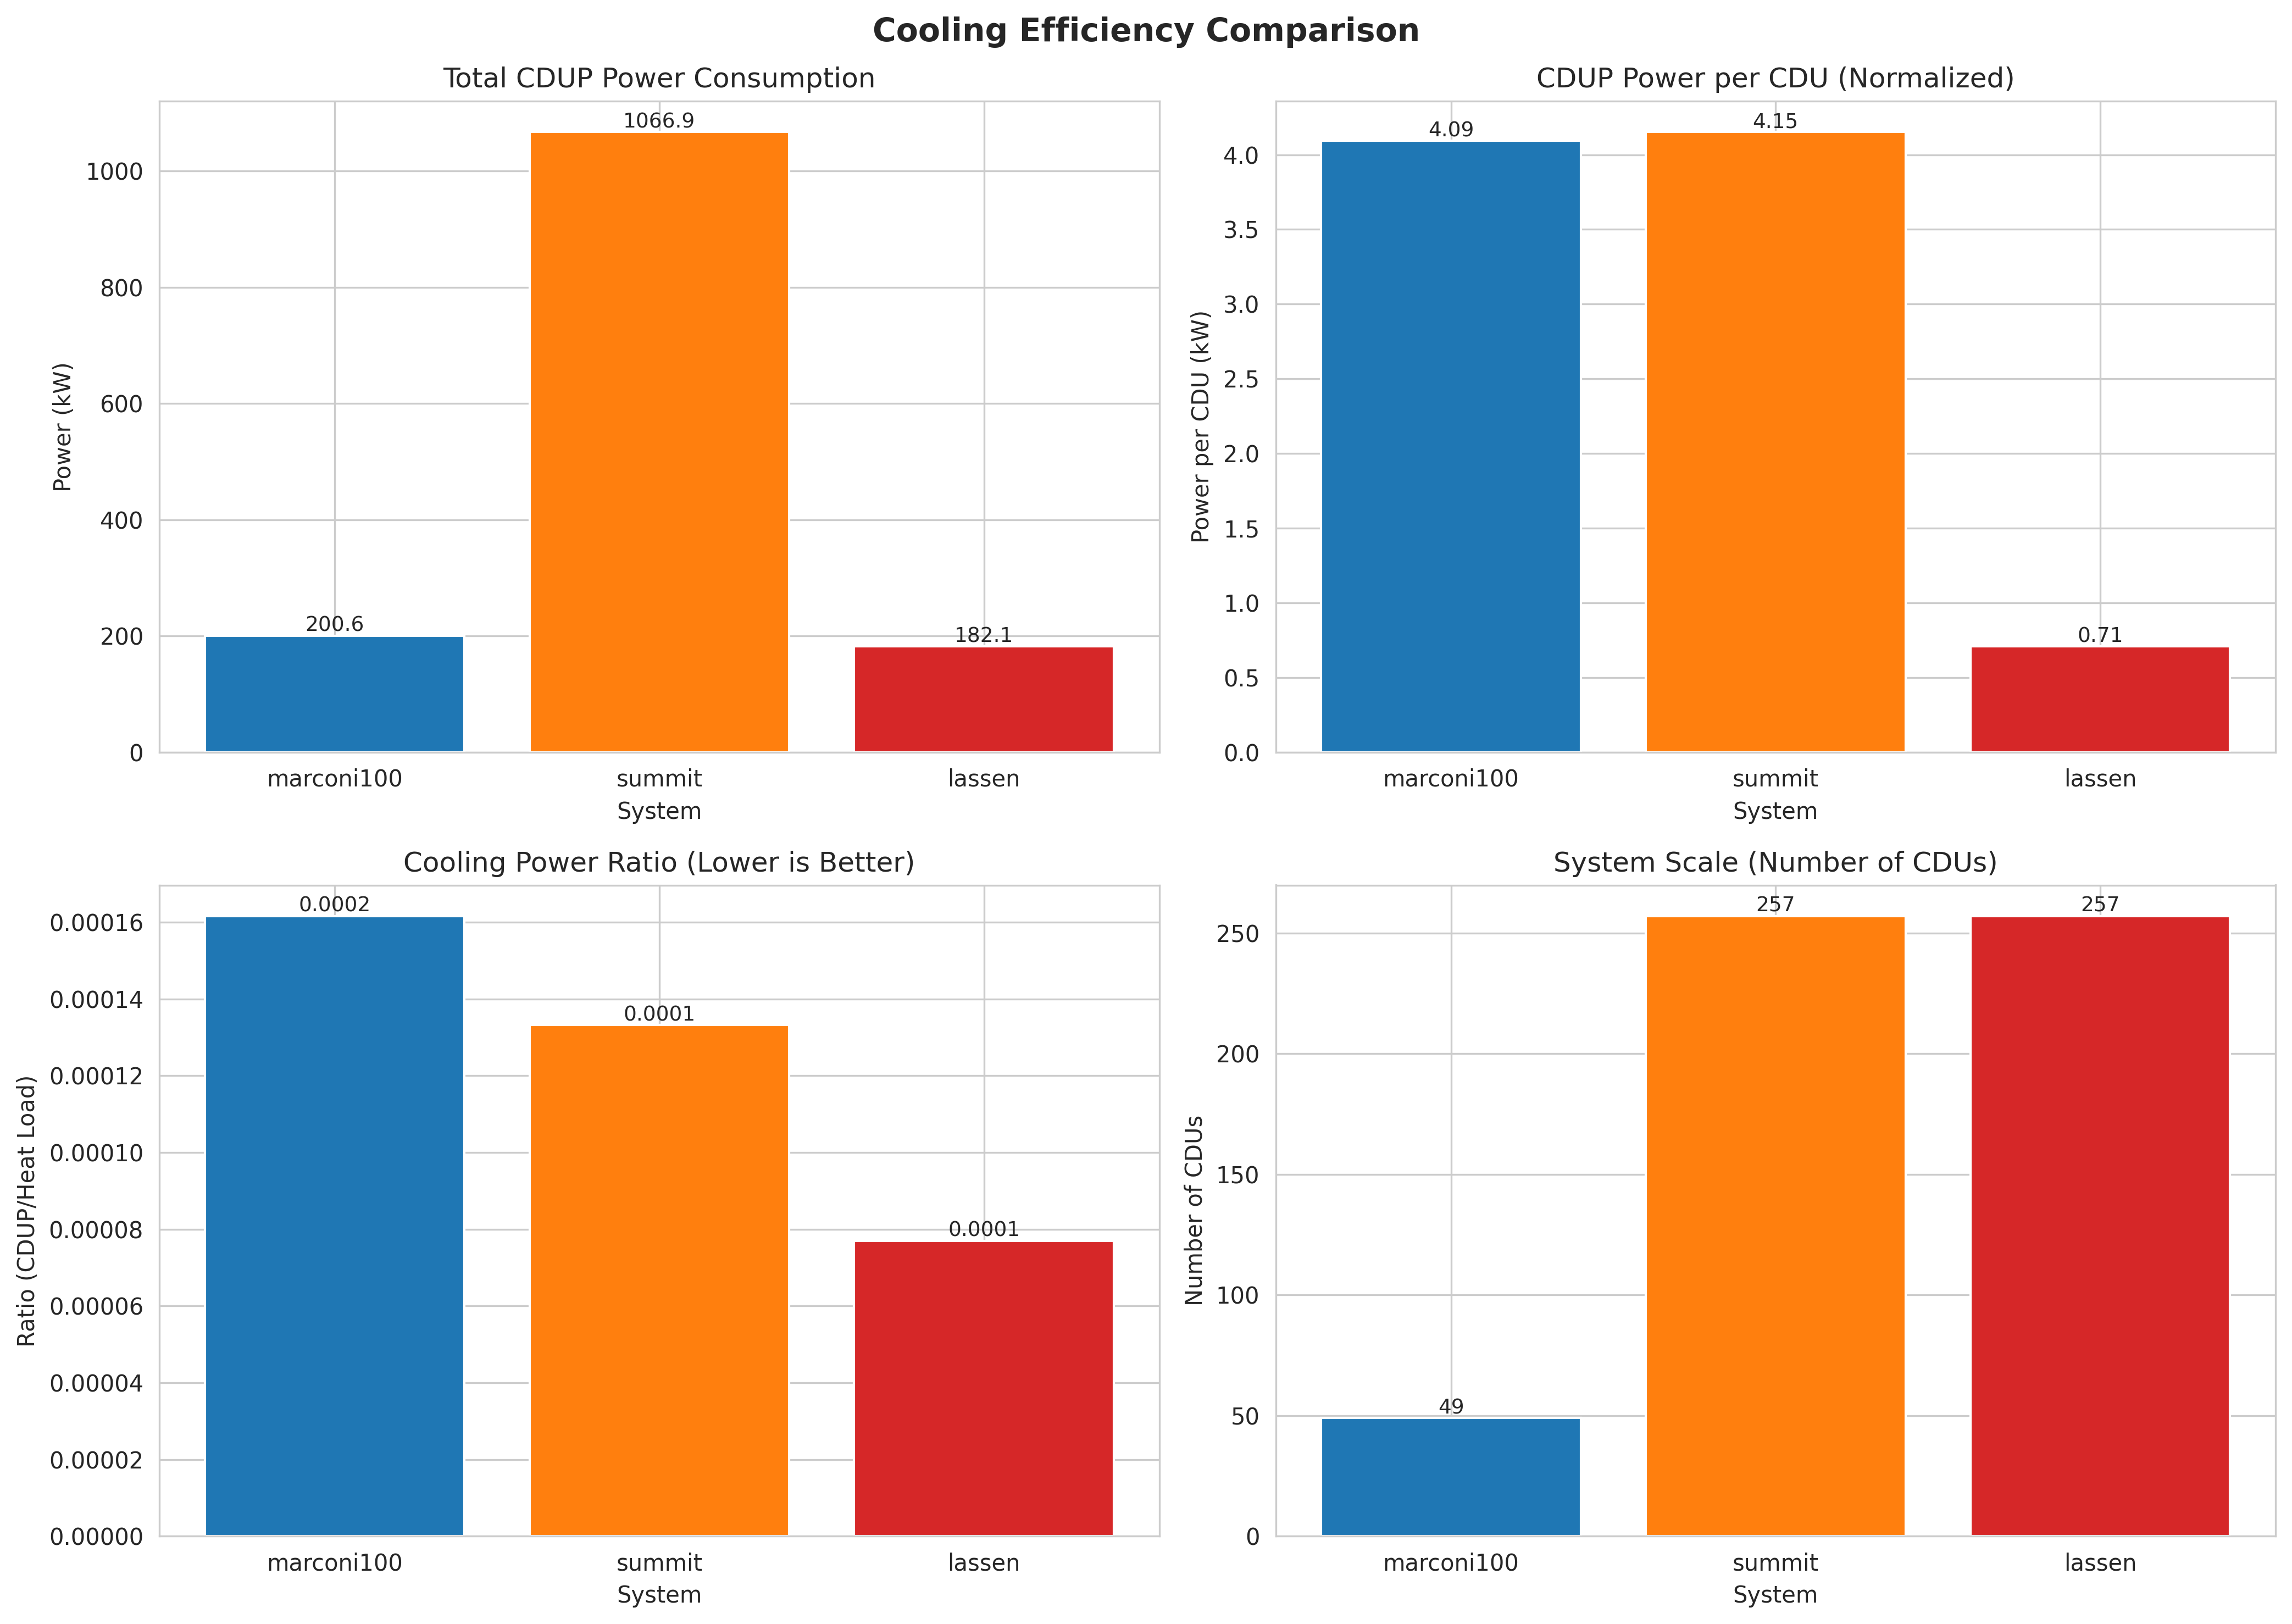

[2/6] Creating thermal response comparison...


2026-01-21 11:52:48 - fmu2ml.analysis.comparative.visualizers.thermal_visualizer - INFO - Saved thermal comparison to ../results/comparative_analysis/system_comparison/thermal_comparison.png


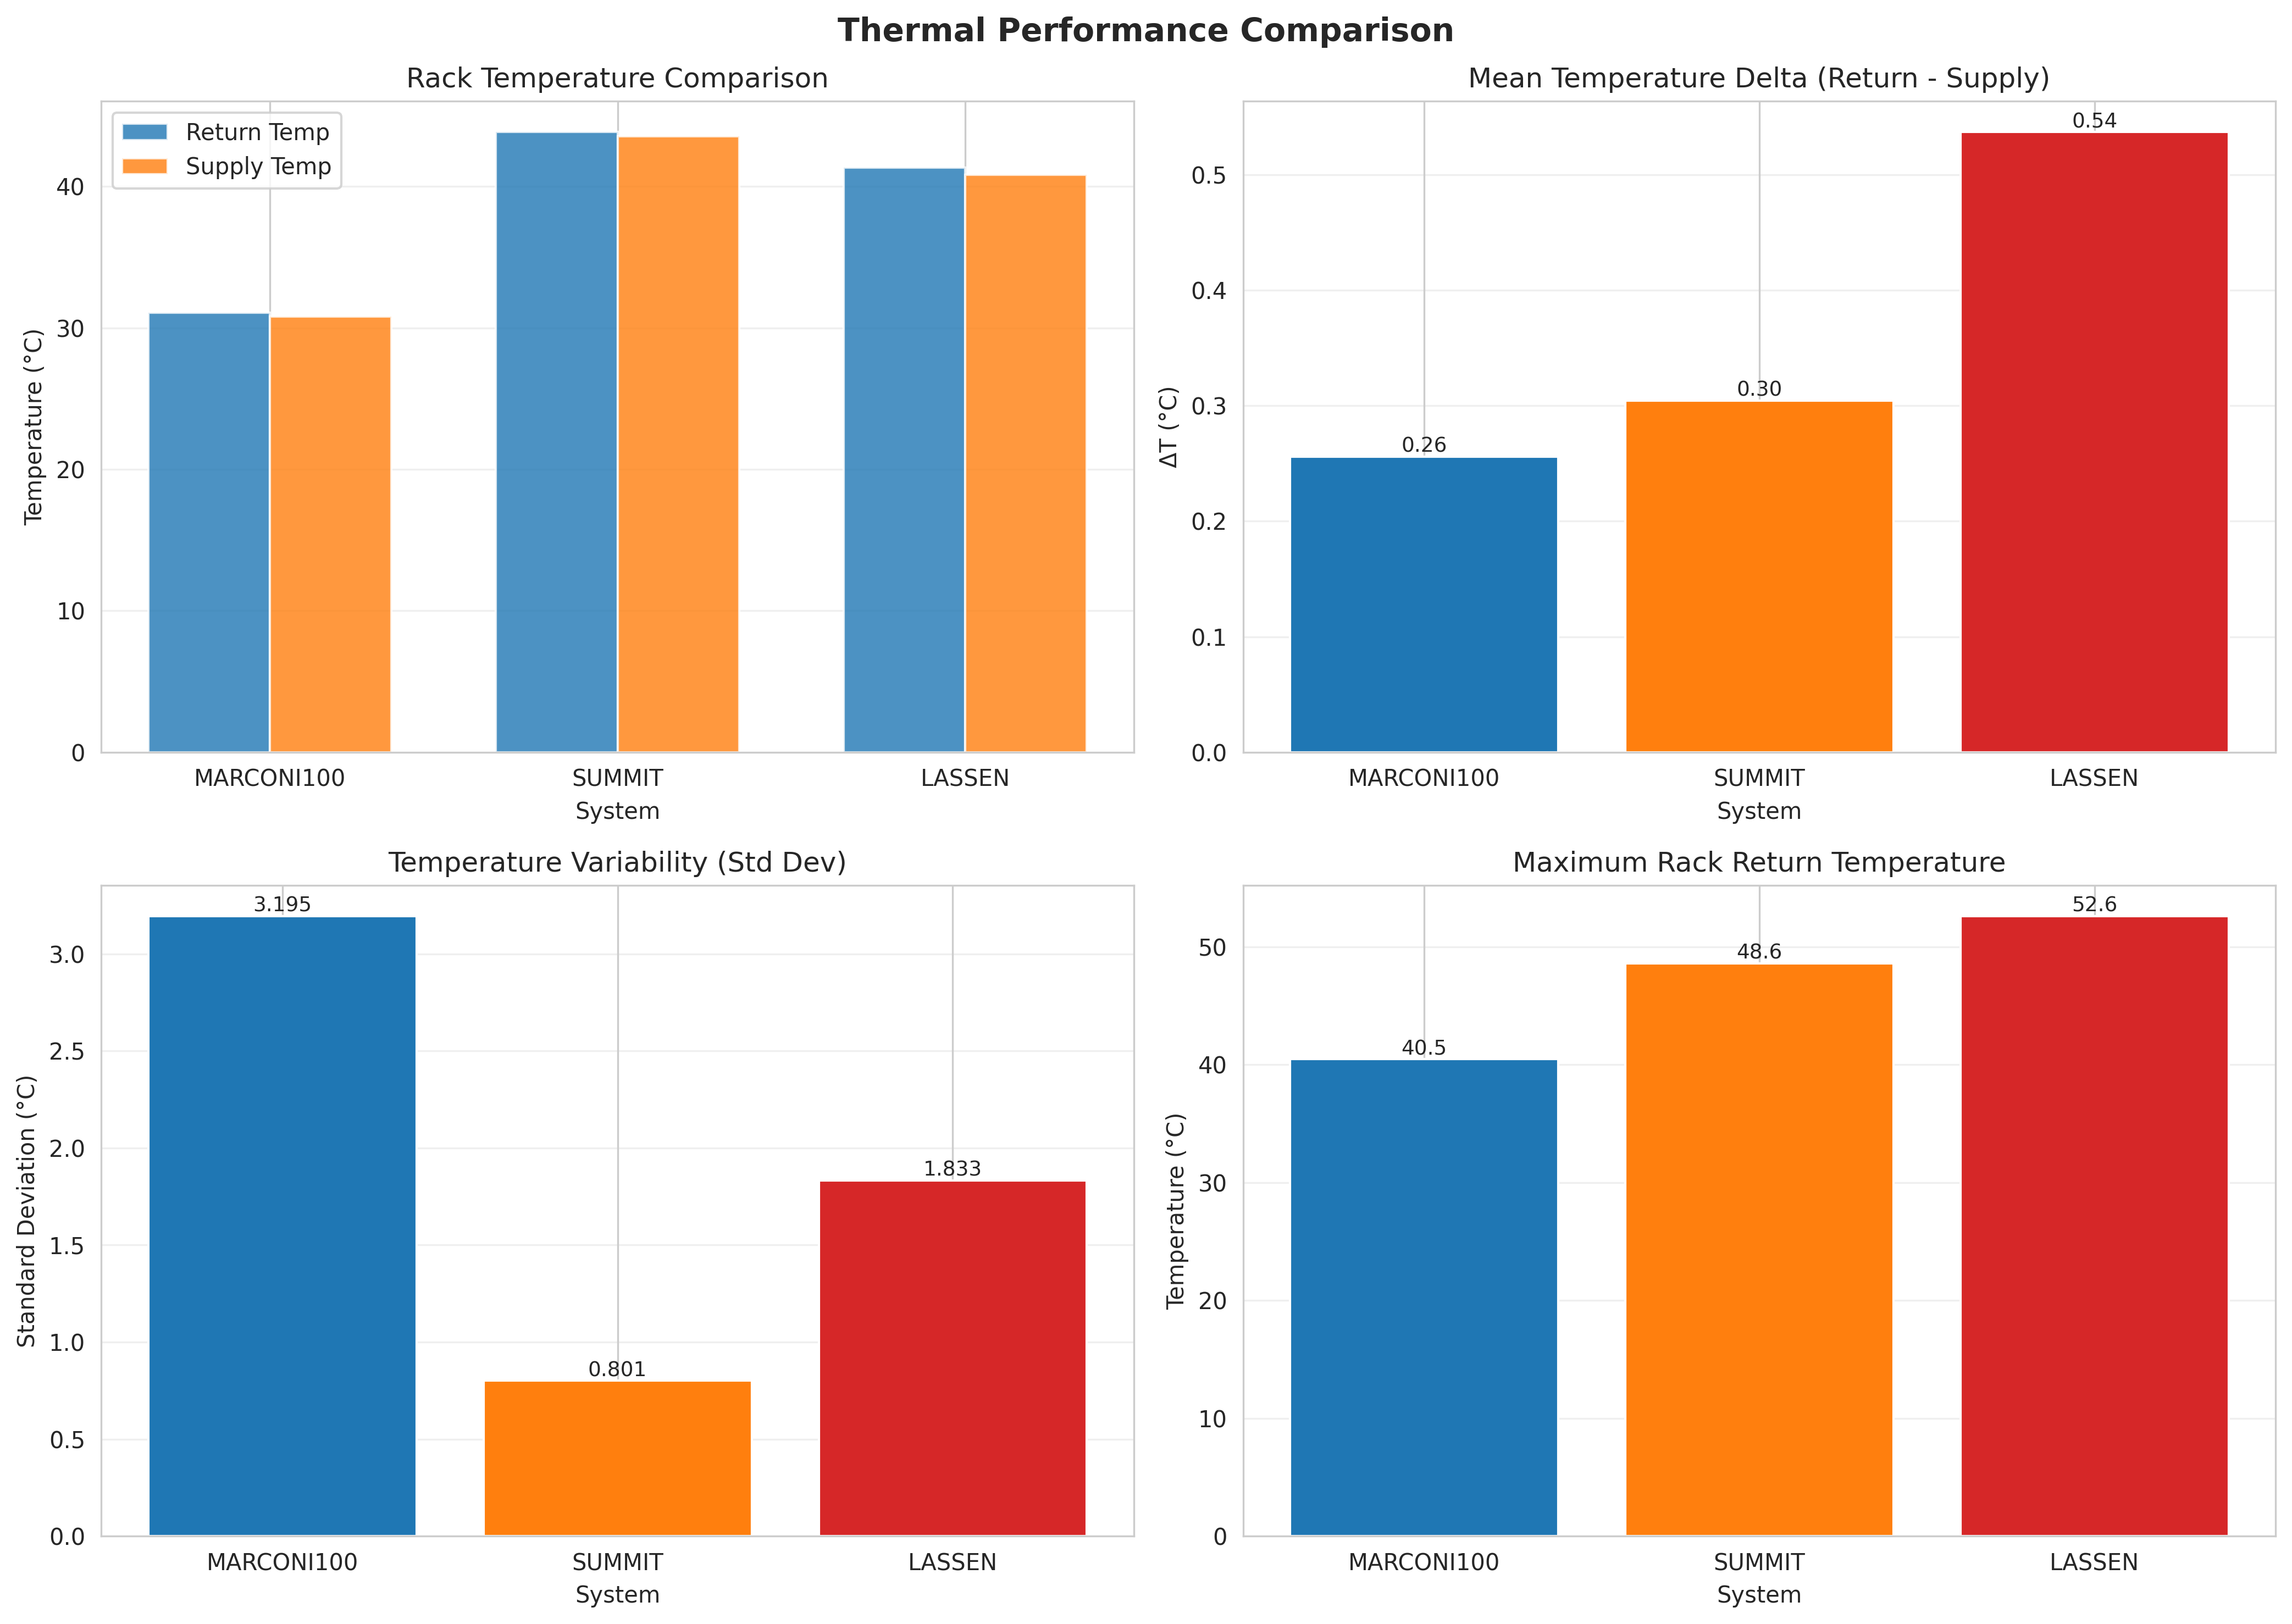

[3/6] Creating power profile comparison...


2026-01-21 11:52:50 - fmu2ml.analysis.comparative.visualizers.power_visualizer - INFO - Saved power profile comparison to ../results/comparative_analysis/system_comparison/power_profile_comparison.png


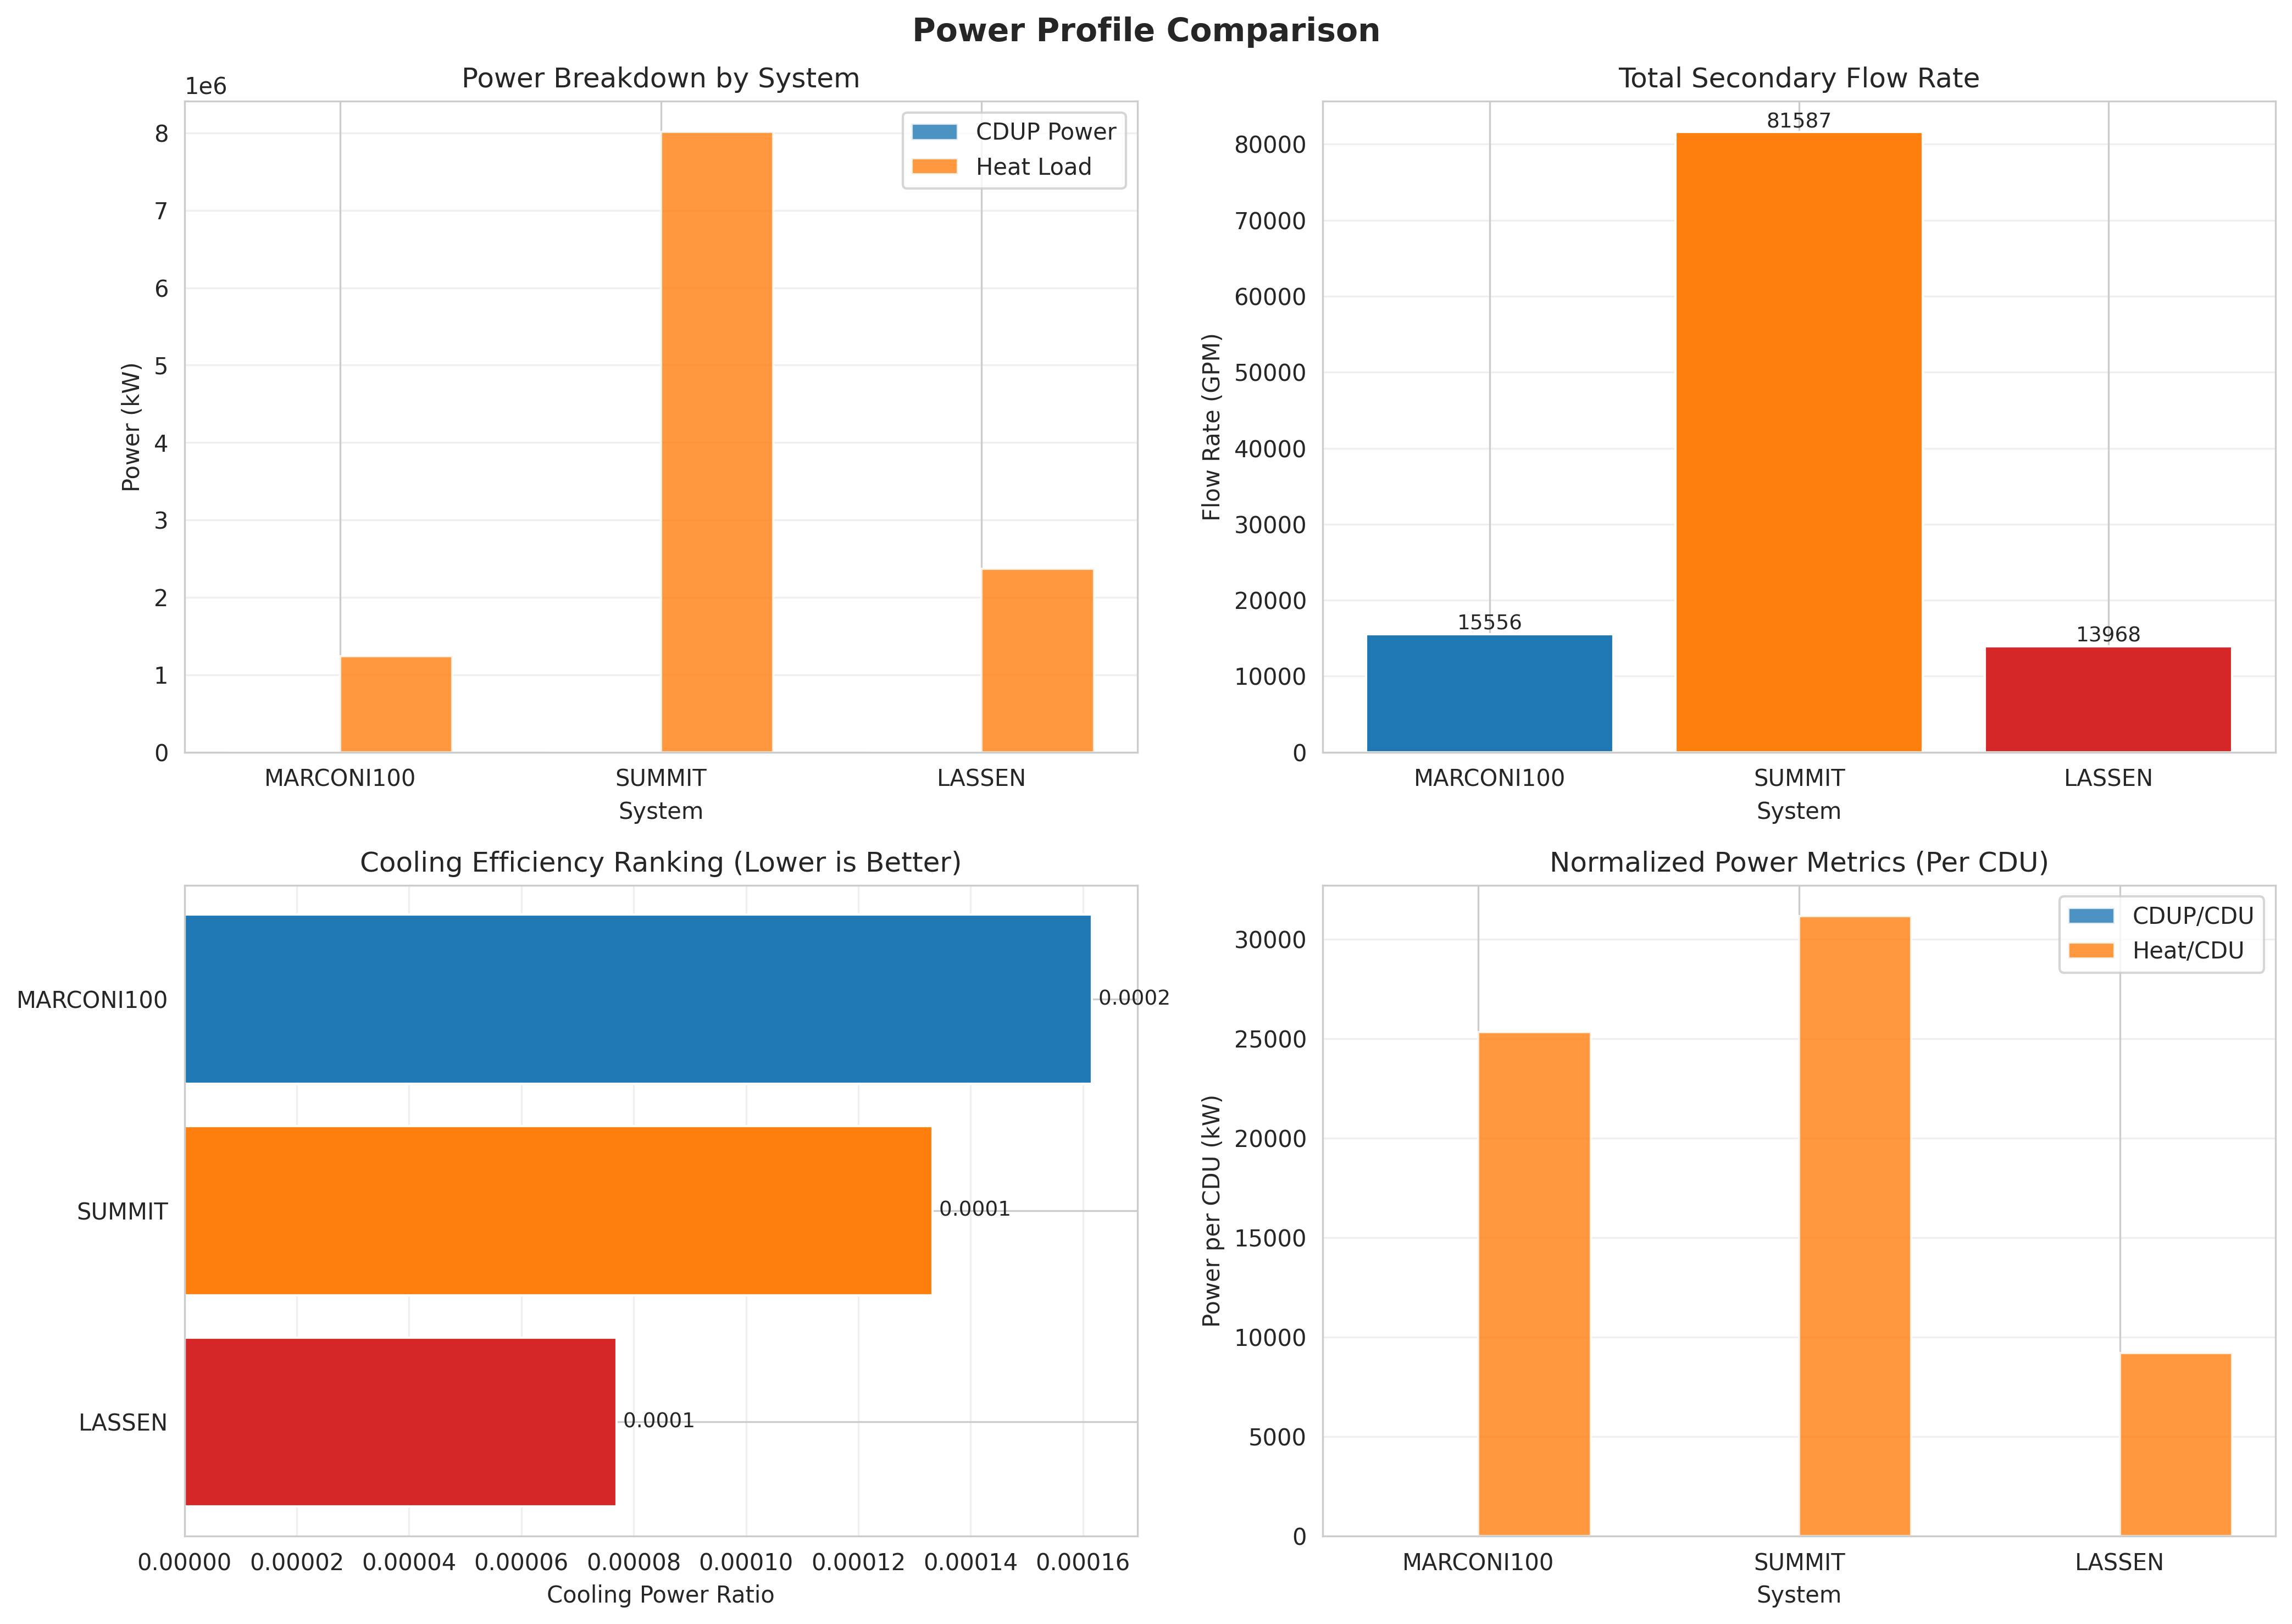

[4/6] Creating scaling analysis plot...


2026-01-21 11:52:52 - fmu2ml.analysis.comparative.visualizers.scaling_visualizer - INFO - Saved scaling analysis to ../results/comparative_analysis/system_comparison/scaling_analysis.png


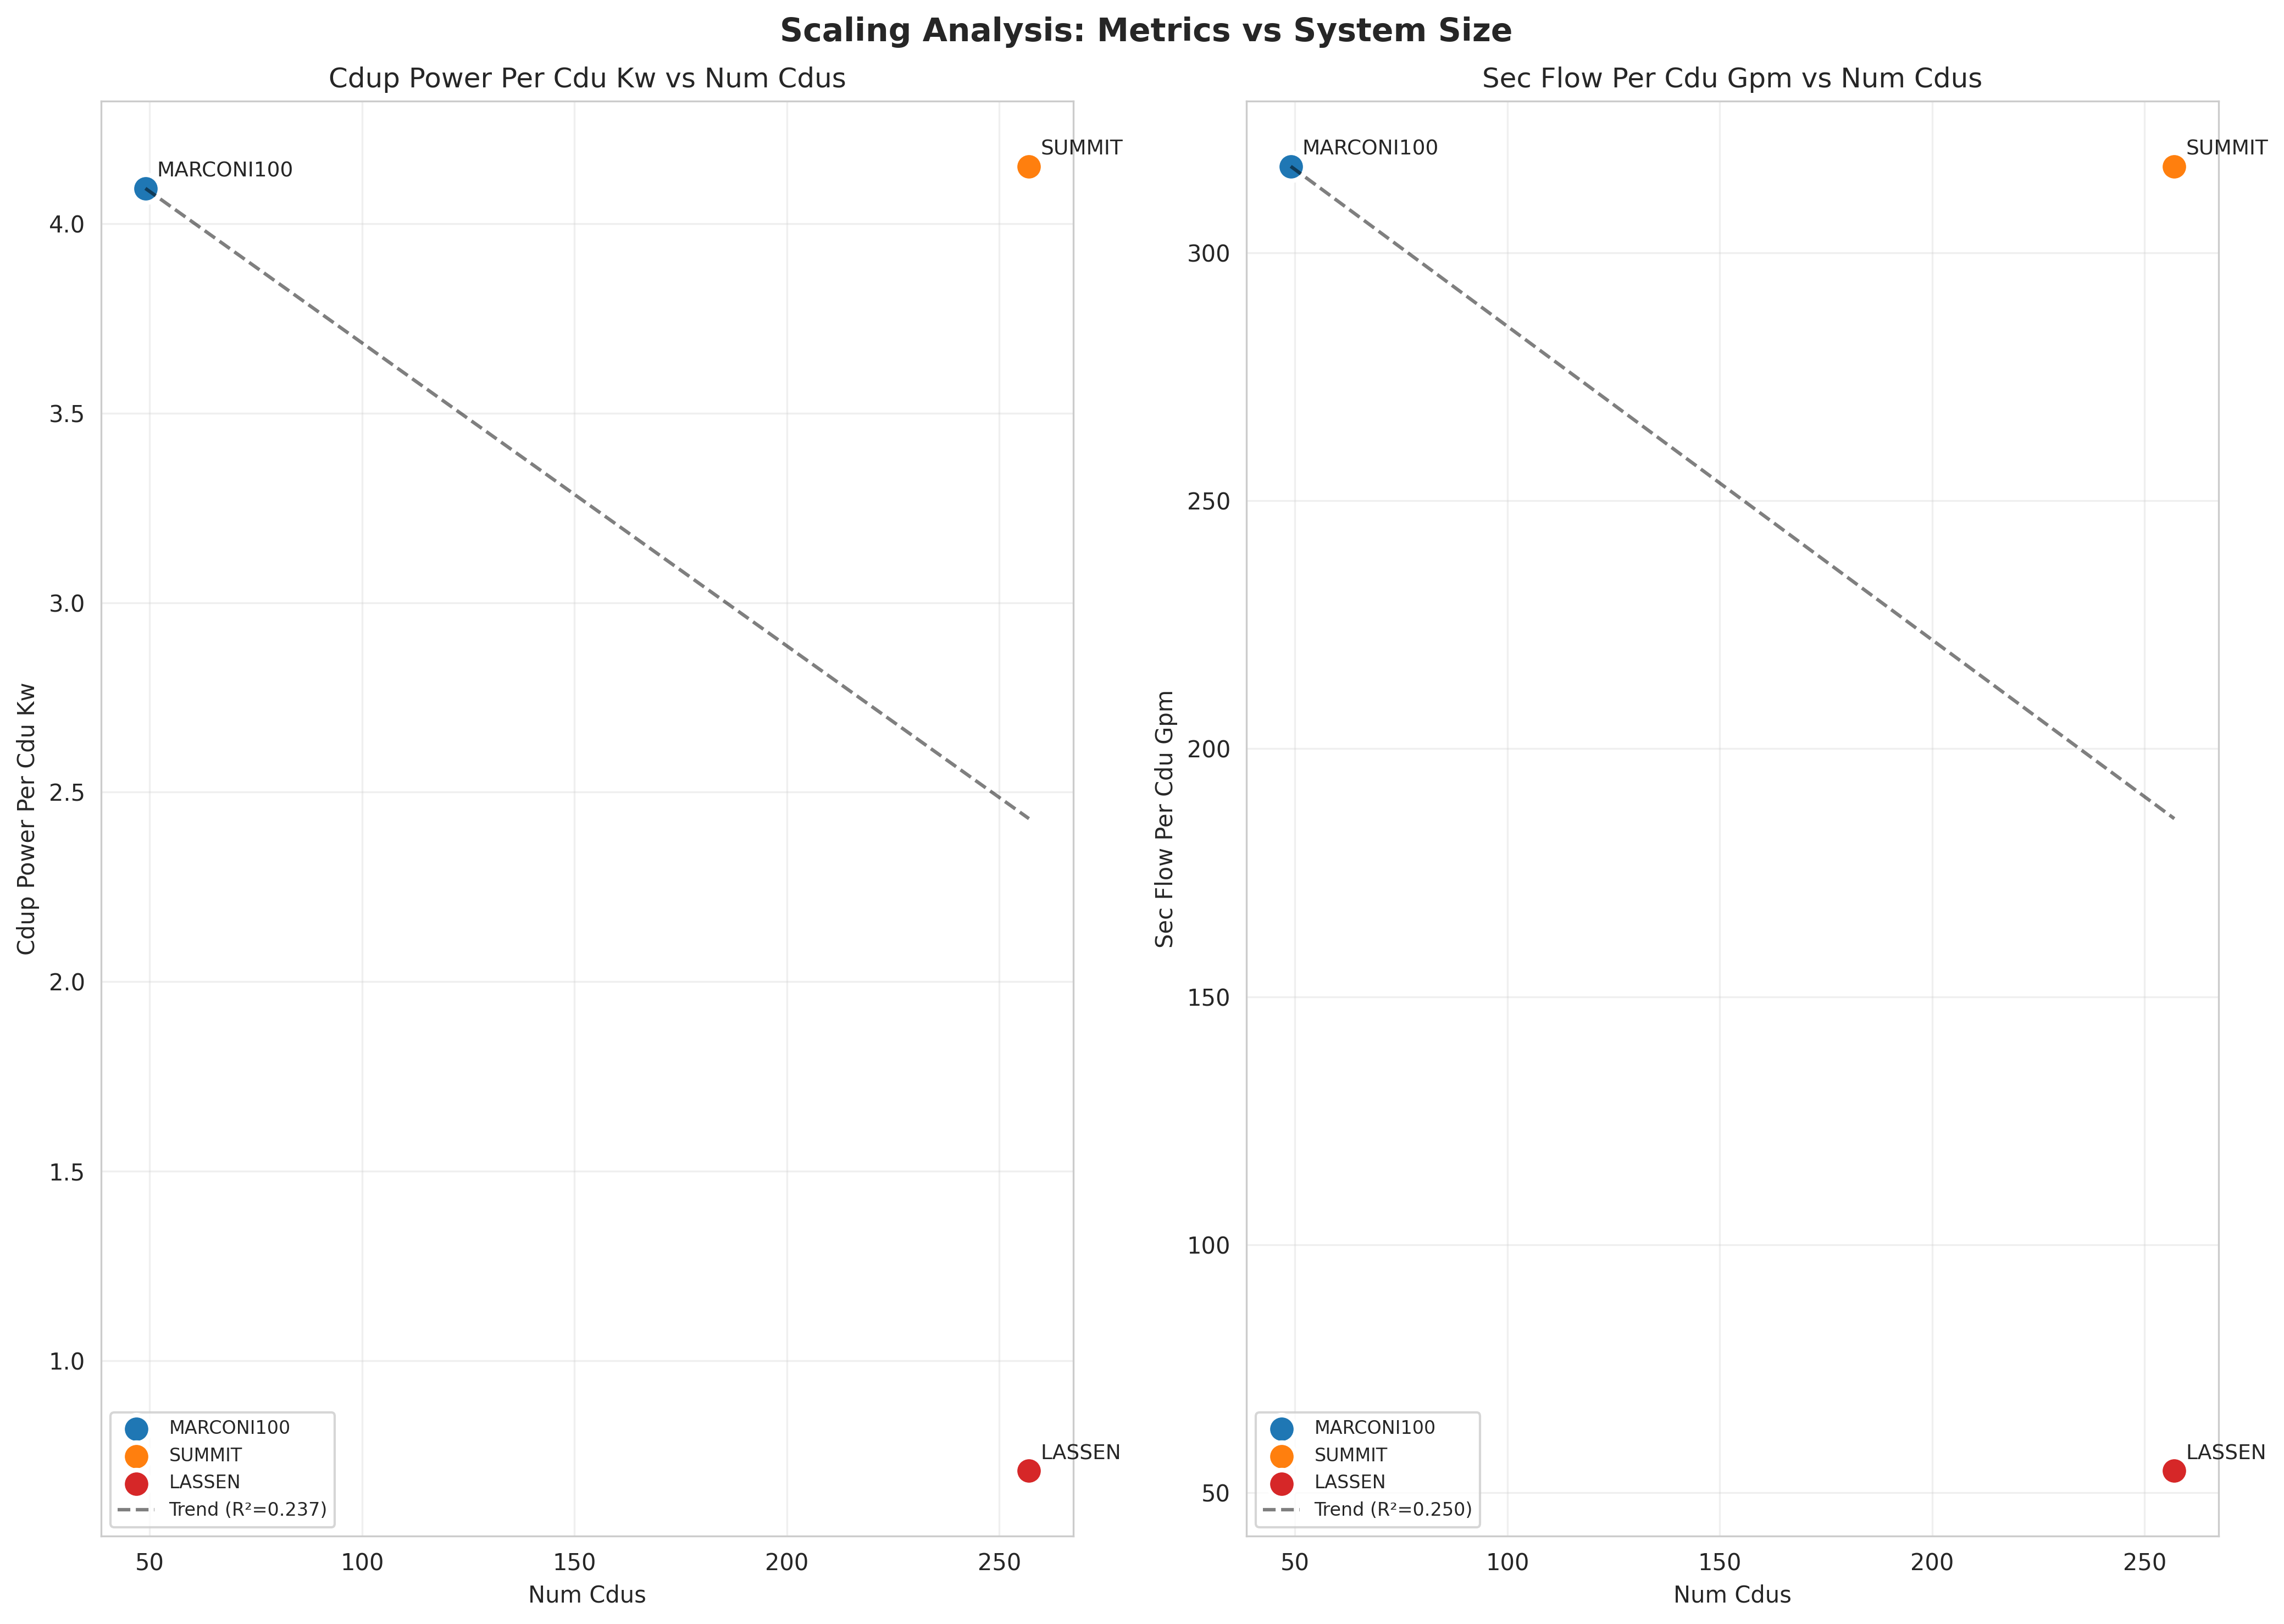

[5/6] Creating radar comparison chart...


2026-01-21 11:52:53 - fmu2ml.analysis.comparative.visualizers.comparison_charts - INFO - Saved radar chart to ../results/comparative_analysis/system_comparison/radar_comparison.png


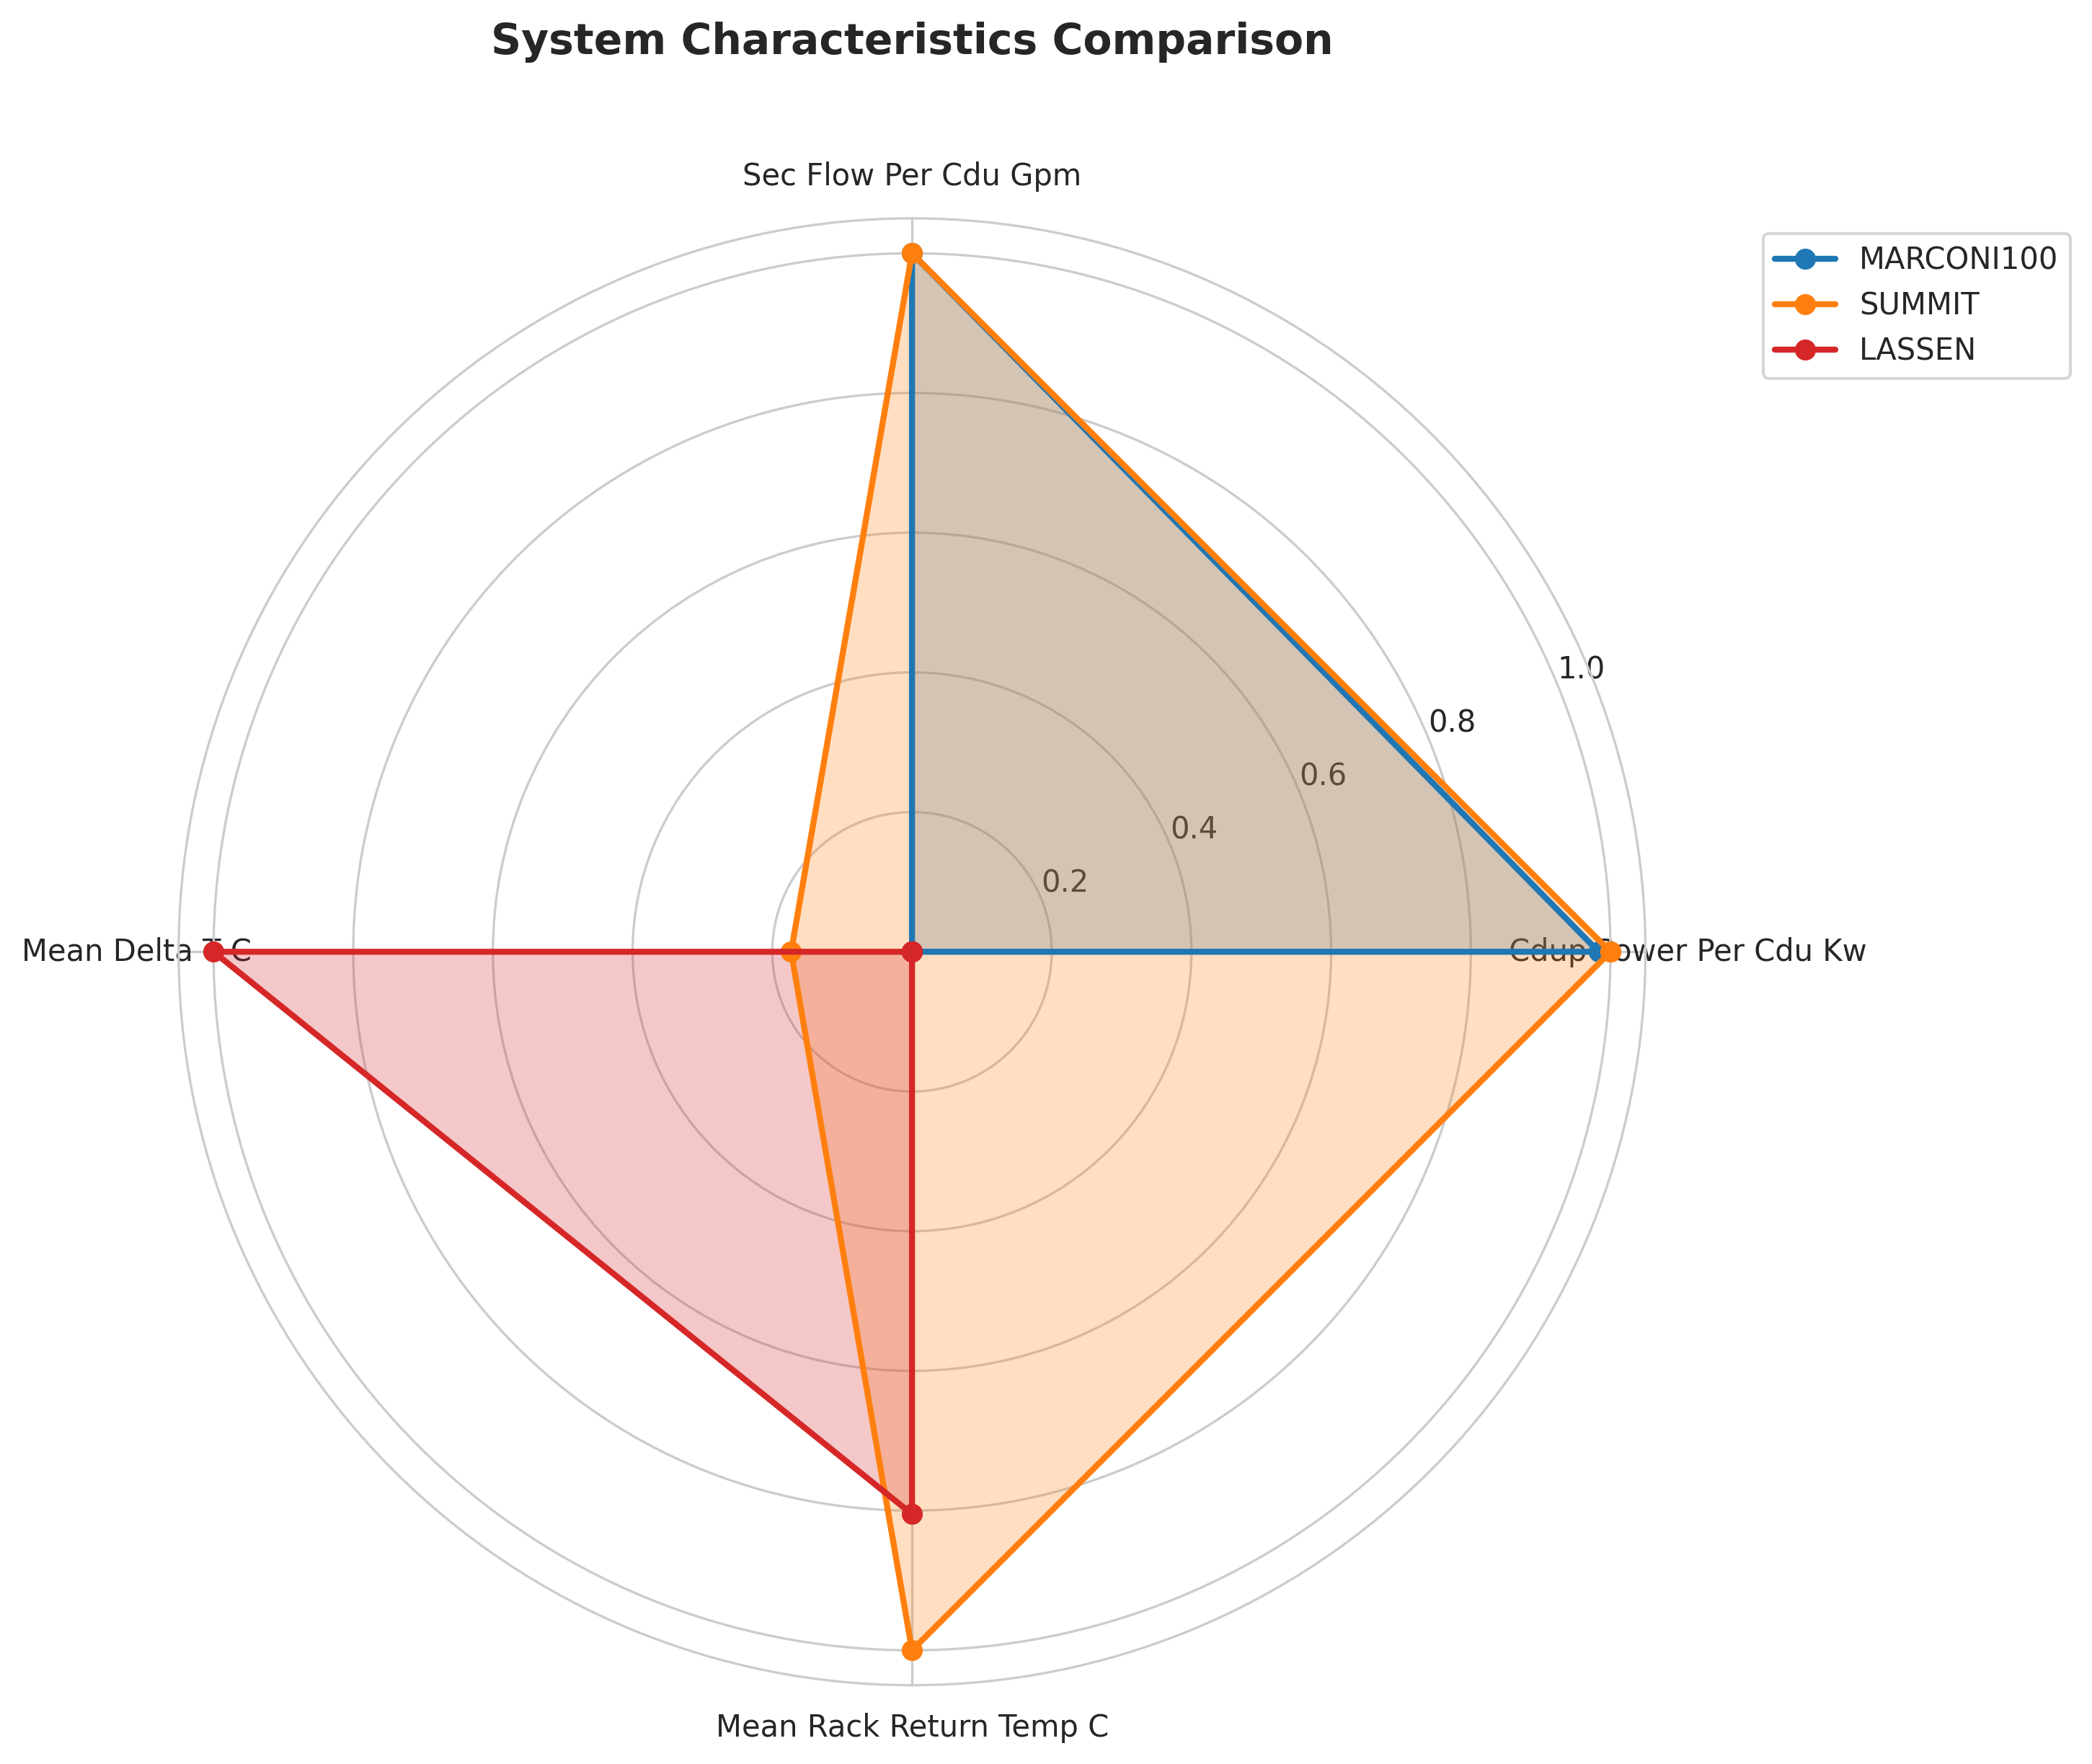

[6/6] Creating system comparison chart...


2026-01-21 11:52:53 - fmu2ml.analysis.comparative.visualizers.comparison_charts - INFO - Saved comparison chart to ../results/comparative_analysis/system_comparison/system_comparison.png


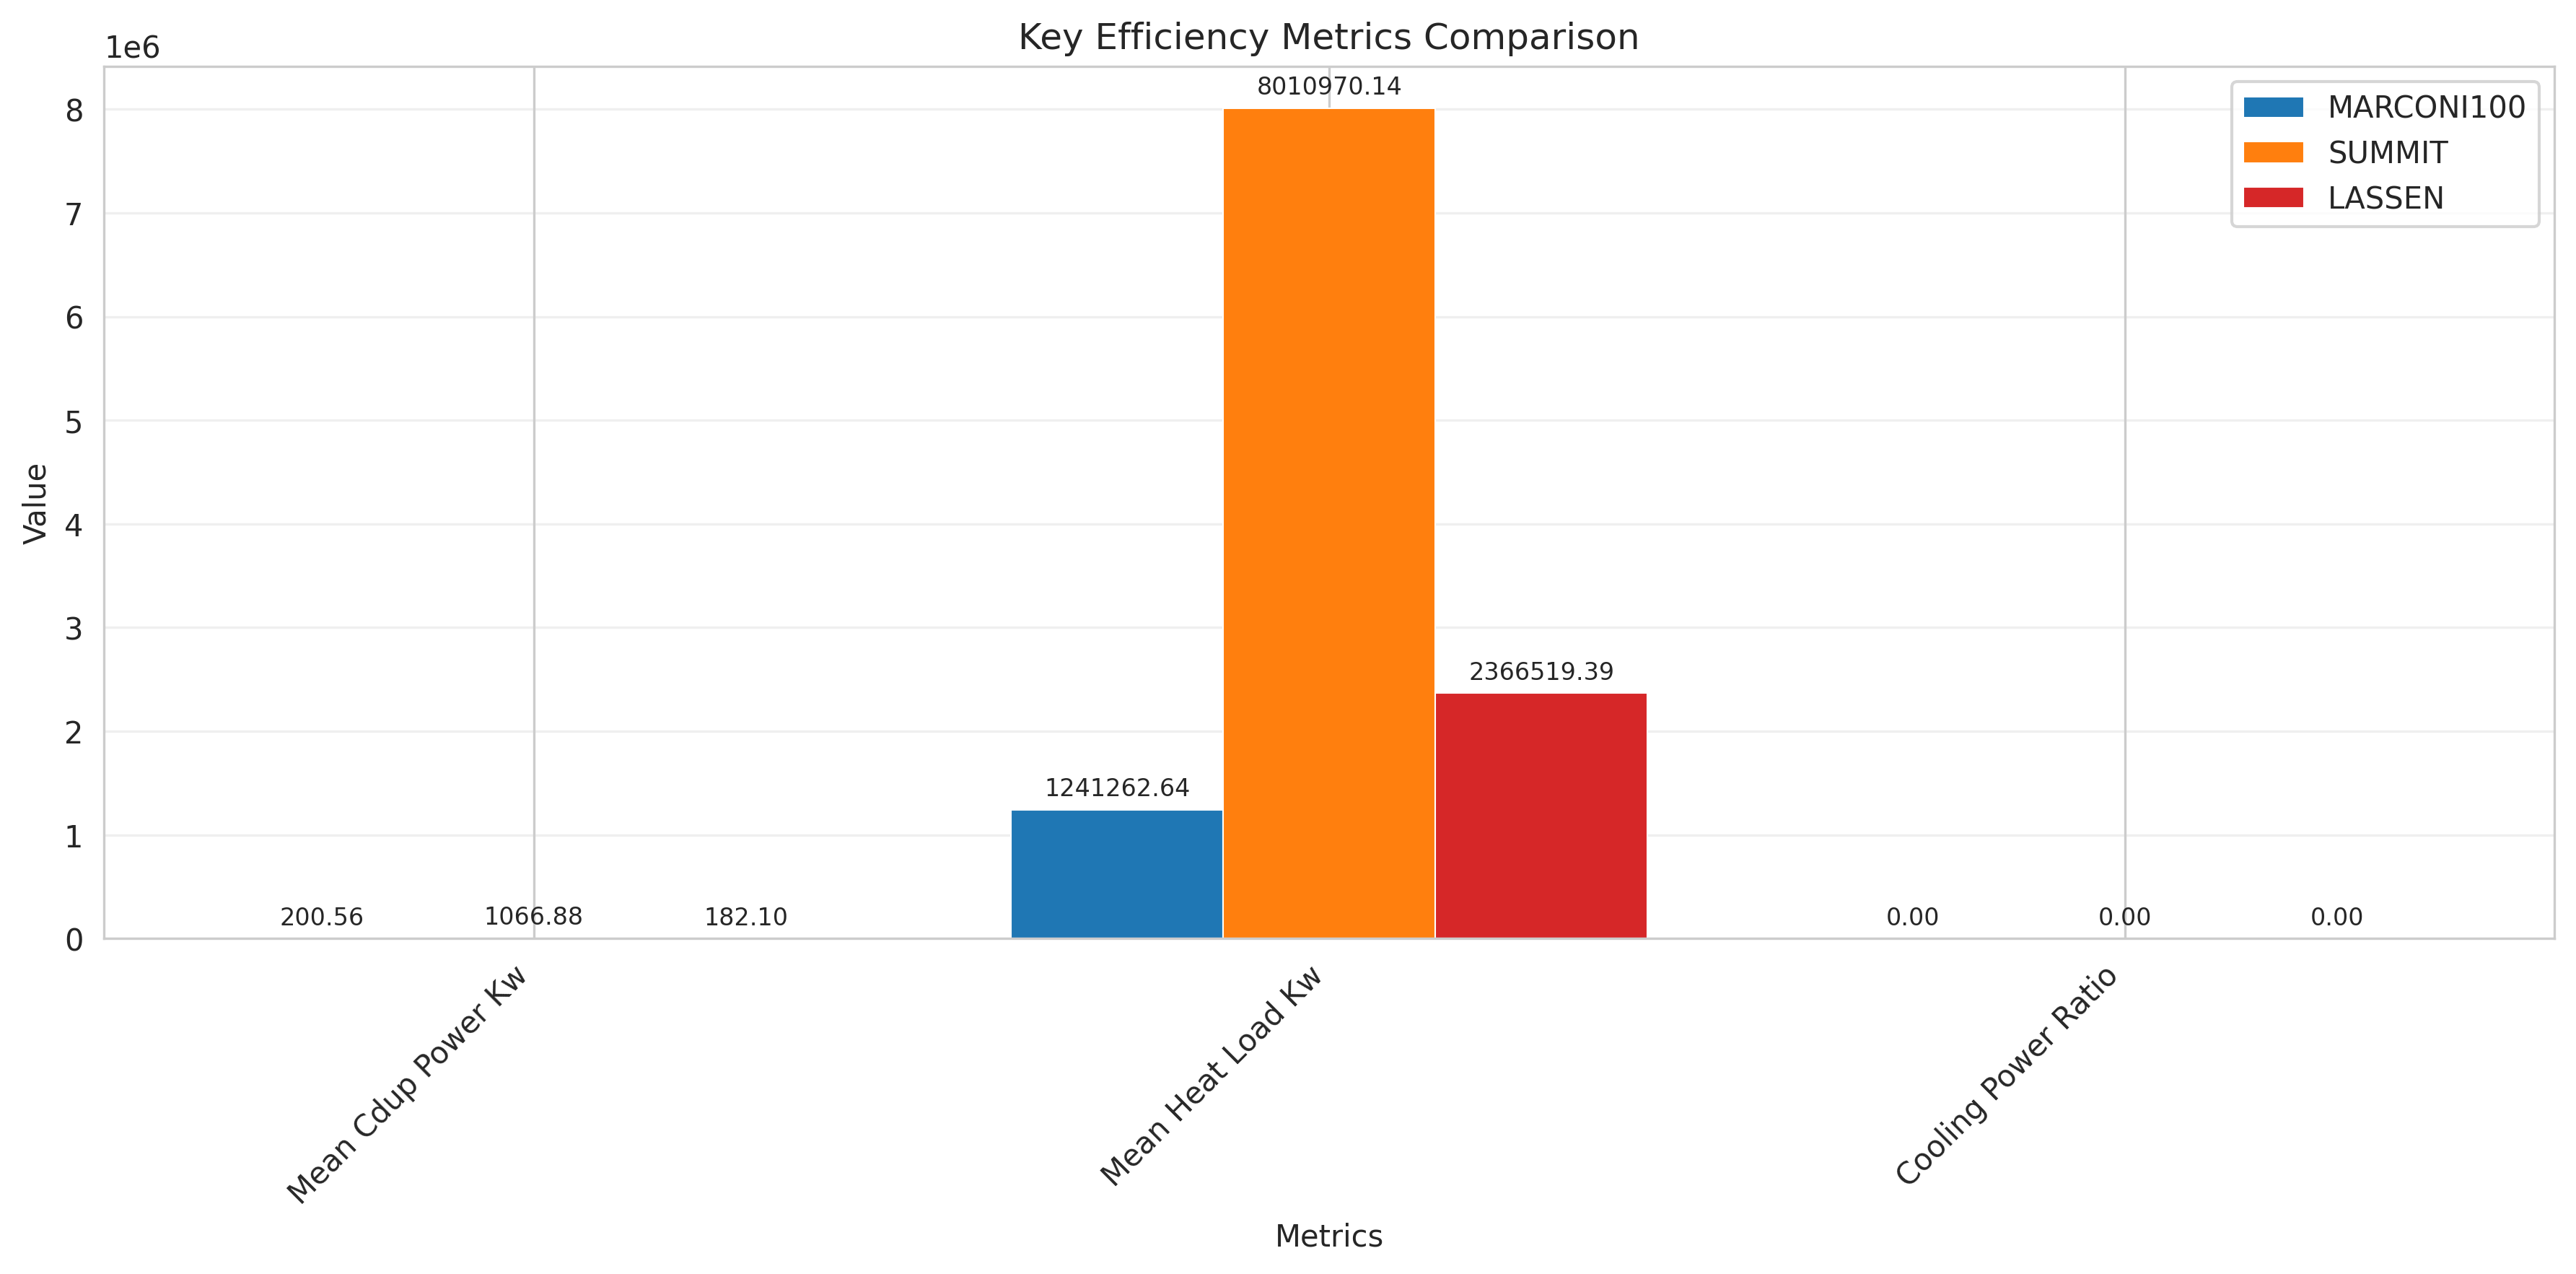


✓ System-level visualizations complete


In [12]:
#  Generate System-Level Visualizations
print("\n" + "="*80)
print("GENERATING SYSTEM-LEVEL VISUALIZATIONS")
print("="*80)

from fmu2ml.analysis.comparative.visualizers import (
    create_system_comparison_chart,
    create_efficiency_comparison_plot,
    create_thermal_response_comparison,
    create_scaling_analysis_plot,
    create_radar_comparison_chart,
    create_power_profile_comparison
)

# Efficiency comparison plot
print("\n[1/6] Creating efficiency comparison plot...")
fig = create_efficiency_comparison_plot(
    efficiency_df,
    output_path=f'{SYSTEM_COMPARISON_DIR}/efficiency_comparison.png'
)
if fig:
    display(Image(filename=f'{SYSTEM_COMPARISON_DIR}/efficiency_comparison.png'))
    plt.close(fig)

# Thermal comparison plot
print("[2/6] Creating thermal response comparison...")
fig = create_thermal_response_comparison(
    thermal_df,
    output_path=f'{SYSTEM_COMPARISON_DIR}/thermal_comparison.png'
)
if fig:
    display(Image(filename=f'{SYSTEM_COMPARISON_DIR}/thermal_comparison.png'))
    plt.close(fig)

# Power profile comparison
print("[3/6] Creating power profile comparison...")
fig = create_power_profile_comparison(
    efficiency_df,
    flow_df,
    output_path=f'{SYSTEM_COMPARISON_DIR}/power_profile_comparison.png'
)
if fig:
    display(Image(filename=f'{SYSTEM_COMPARISON_DIR}/power_profile_comparison.png'))
    plt.close(fig)

# Scaling analysis
print("[4/6] Creating scaling analysis plot...")
fig = create_scaling_analysis_plot(
    normalized_df,
    output_path=f'{SYSTEM_COMPARISON_DIR}/scaling_analysis.png'
)
if fig:
    display(Image(filename=f'{SYSTEM_COMPARISON_DIR}/scaling_analysis.png'))
    plt.close(fig)

# Radar comparison
print("[5/6] Creating radar comparison chart...")
radar_metrics = ['cdup_power_per_cdu_kw', 'sec_flow_per_cdu_gpm', 
                 'mean_delta_t_c', 'mean_rack_return_temp_c']
available_radar = [m for m in radar_metrics if m in normalized_df.columns]

if len(available_radar) >= 3:
    fig = create_radar_comparison_chart(
        normalized_df,
        metrics=available_radar,
        output_path=f'{SYSTEM_COMPARISON_DIR}/radar_comparison.png'
    )
    if fig:
        display(Image(filename=f'{SYSTEM_COMPARISON_DIR}/radar_comparison.png'))
        plt.close(fig)

# System comparison chart
print("[6/6] Creating system comparison chart...")
comparison_metrics = ['mean_cdup_power_kw', 'mean_heat_load_kw', 'cooling_power_ratio']
available_metrics = [m for m in comparison_metrics if m in efficiency_df.columns]

if available_metrics:
    fig = create_system_comparison_chart(
        efficiency_df,
        metric_columns=available_metrics,
        title="Key Efficiency Metrics Comparison",
        output_path=f'{SYSTEM_COMPARISON_DIR}/system_comparison.png'
    )
    if fig:
        display(Image(filename=f'{SYSTEM_COMPARISON_DIR}/system_comparison.png'))
        plt.close(fig)

print("\n✓ System-level visualizations complete")

In [13]:
# Physics Constraint Validation
print("\n" + "="*80)
print("PHYSICS CONSTRAINT VALIDATION")
print("="*80)

validator = PhysicsConstraintValidator()

# Validate each system
validation_results = {}
for system_name in SYSTEMS:
    print(f"\nValidating {system_name}...")
    data = comparator.system_data[system_name]
    results = validator.validate_all(data)
    validation_results[system_name] = results
    
    print(f"  Total constraints: {results['summary']['total_constraints']}")
    print(f"  Passed: {results['summary']['passed']}")
    print(f"  Failed: {results['summary']['failed']}")
    print(f"  Pass rate: {results['summary']['pass_rate']:.1%}")

# Compare physics validation across models
comparison = validator.compare_models(comparator.system_data)

display(Markdown("### Physics Validation Summary"))
summary_df = pd.DataFrame(comparison['summary_table'])
display(summary_df)

# Save validation results
import json
with open(f'{PHYSICS_VALIDATION_DIR}/validation_results.json', 'w') as f:
    json.dump(comparison, f, indent=2, default=str)

print(f"\n✓ Validation results saved to {PHYSICS_VALIDATION_DIR}")

2026-01-21 11:52:54 - fmu2ml.analysis.comparative.analyzers.physics_validator - INFO - Validating physics constraints for marconi100...
2026-01-21 11:52:54 - fmu2ml.analysis.comparative.analyzers.physics_validator - INFO - Validating physics constraints for summit...
2026-01-21 11:52:54 - fmu2ml.analysis.comparative.analyzers.physics_validator - INFO - Validating physics constraints for lassen...



PHYSICS CONSTRAINT VALIDATION

Validating marconi100...
  Total constraints: 6
  Passed: 6
  Failed: 1
  Pass rate: 85.7%

Validating summit...
  Total constraints: 6
  Passed: 4
  Failed: 3
  Pass rate: 57.1%

Validating lassen...
  Total constraints: 6
  Passed: 4
  Failed: 3
  Pass rate: 57.1%


### Physics Validation Summary

,model,temperature_ordering,approach_temperature,mass_conservation,pue_bounds,energy_balance,monotonicity,hx_effectiveness,pass_rate
0,marconi100,✓,✓,✓,✓,✗,✓,✓,0.857143
1,summit,✓,✓,✓,✓,✗,✓,✗,0.714286
2,lassen,✓,✓,✓,✓,✗,✗,✗,0.571429



✓ Validation results saved to ../results/comparative_analysis/physics_validation



PHYSICS VALIDATION VISUALIZATIONS

[1/3] Creating physics validation summary...


2026-01-21 11:52:54 - fmu2ml.analysis.comparative.visualizers.simple_comparison_visualizer - INFO - Saved: ../results/comparative_analysis/physics_validation/physics_validation_summary.png


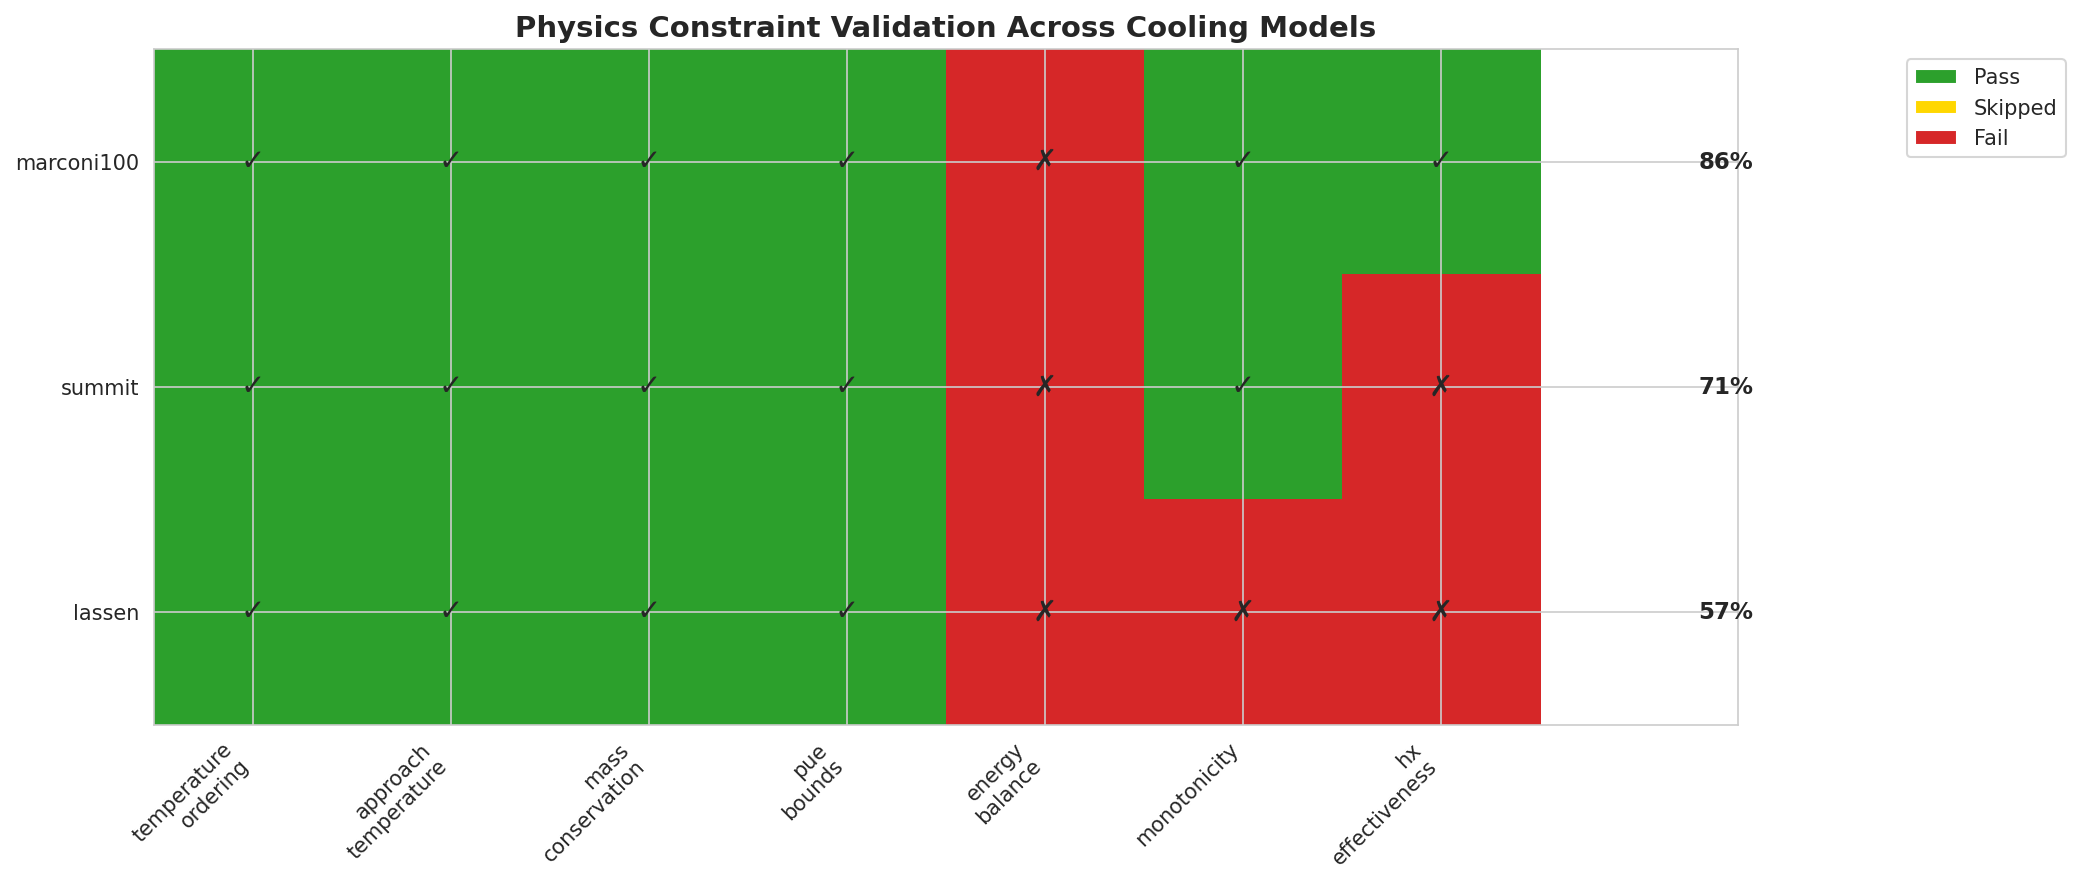

[2/3] Creating physics metrics comparison...


2026-01-21 11:52:55 - fmu2ml.analysis.comparative.visualizers.simple_comparison_visualizer - INFO - Saved: ../results/comparative_analysis/physics_validation/physics_metrics_comparison.png


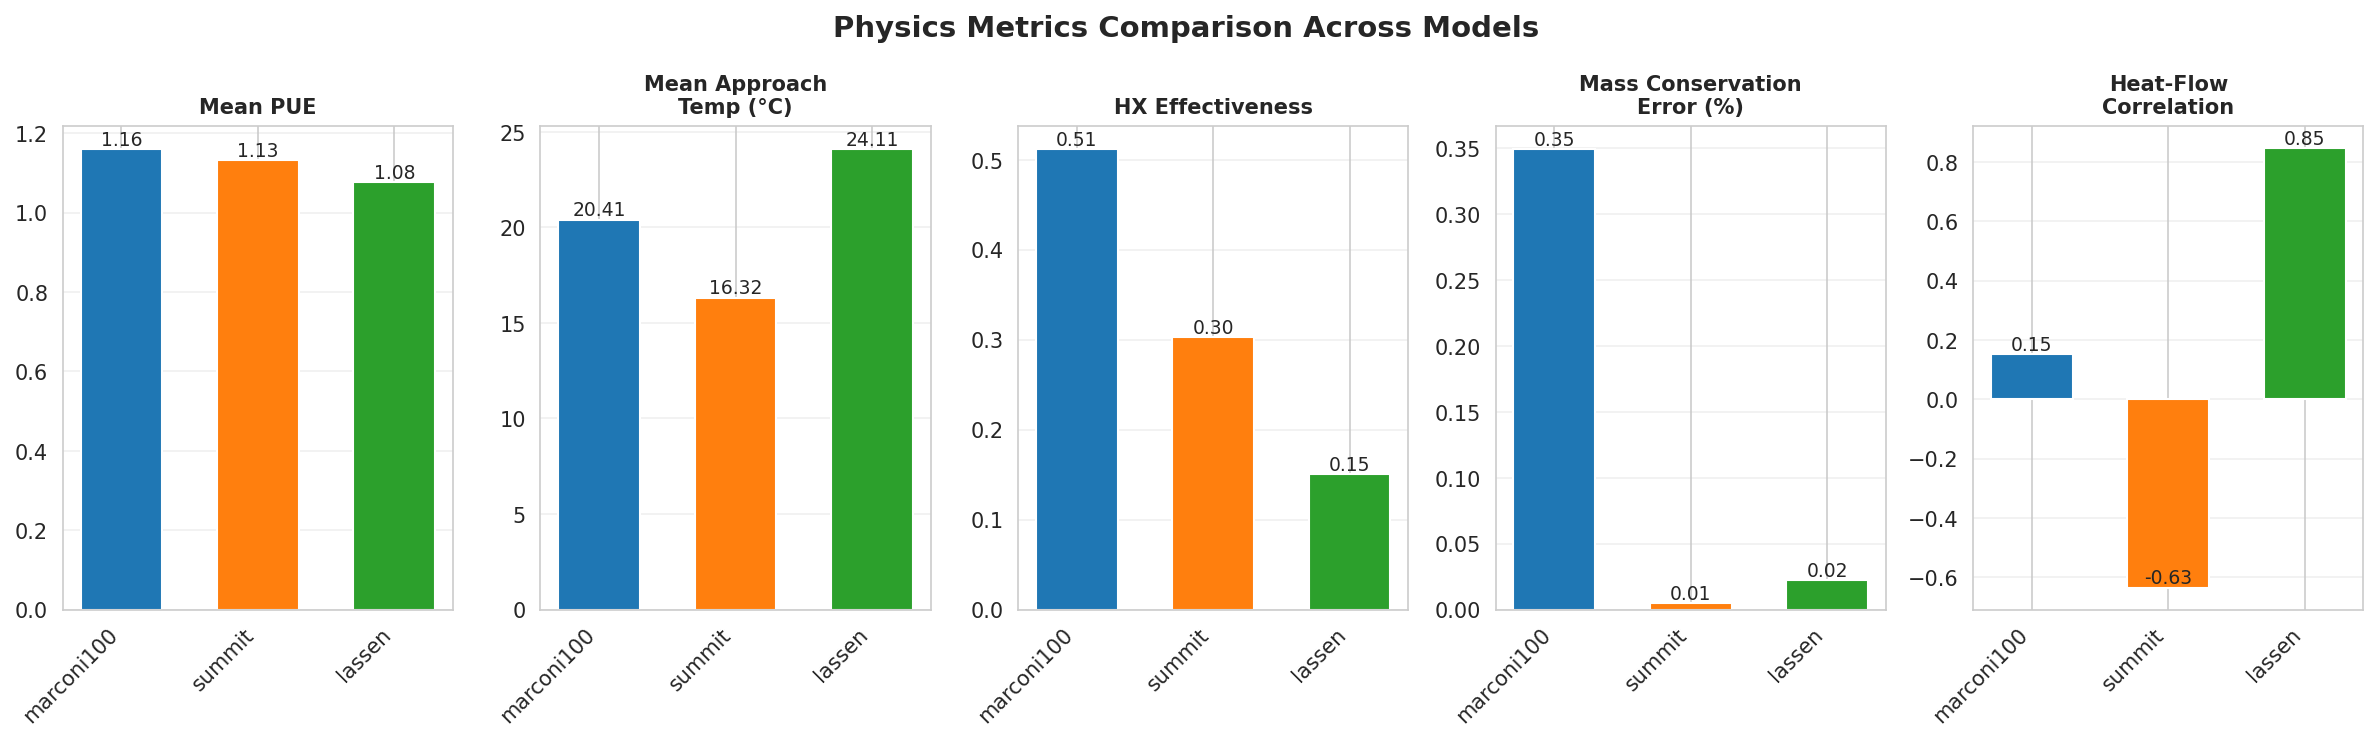

[3/3] Creating I/O distributions...


2026-01-21 11:52:57 - fmu2ml.analysis.comparative.visualizers.simple_comparison_visualizer - INFO - Saved: ../results/comparative_analysis/physics_validation/io_distributions.png


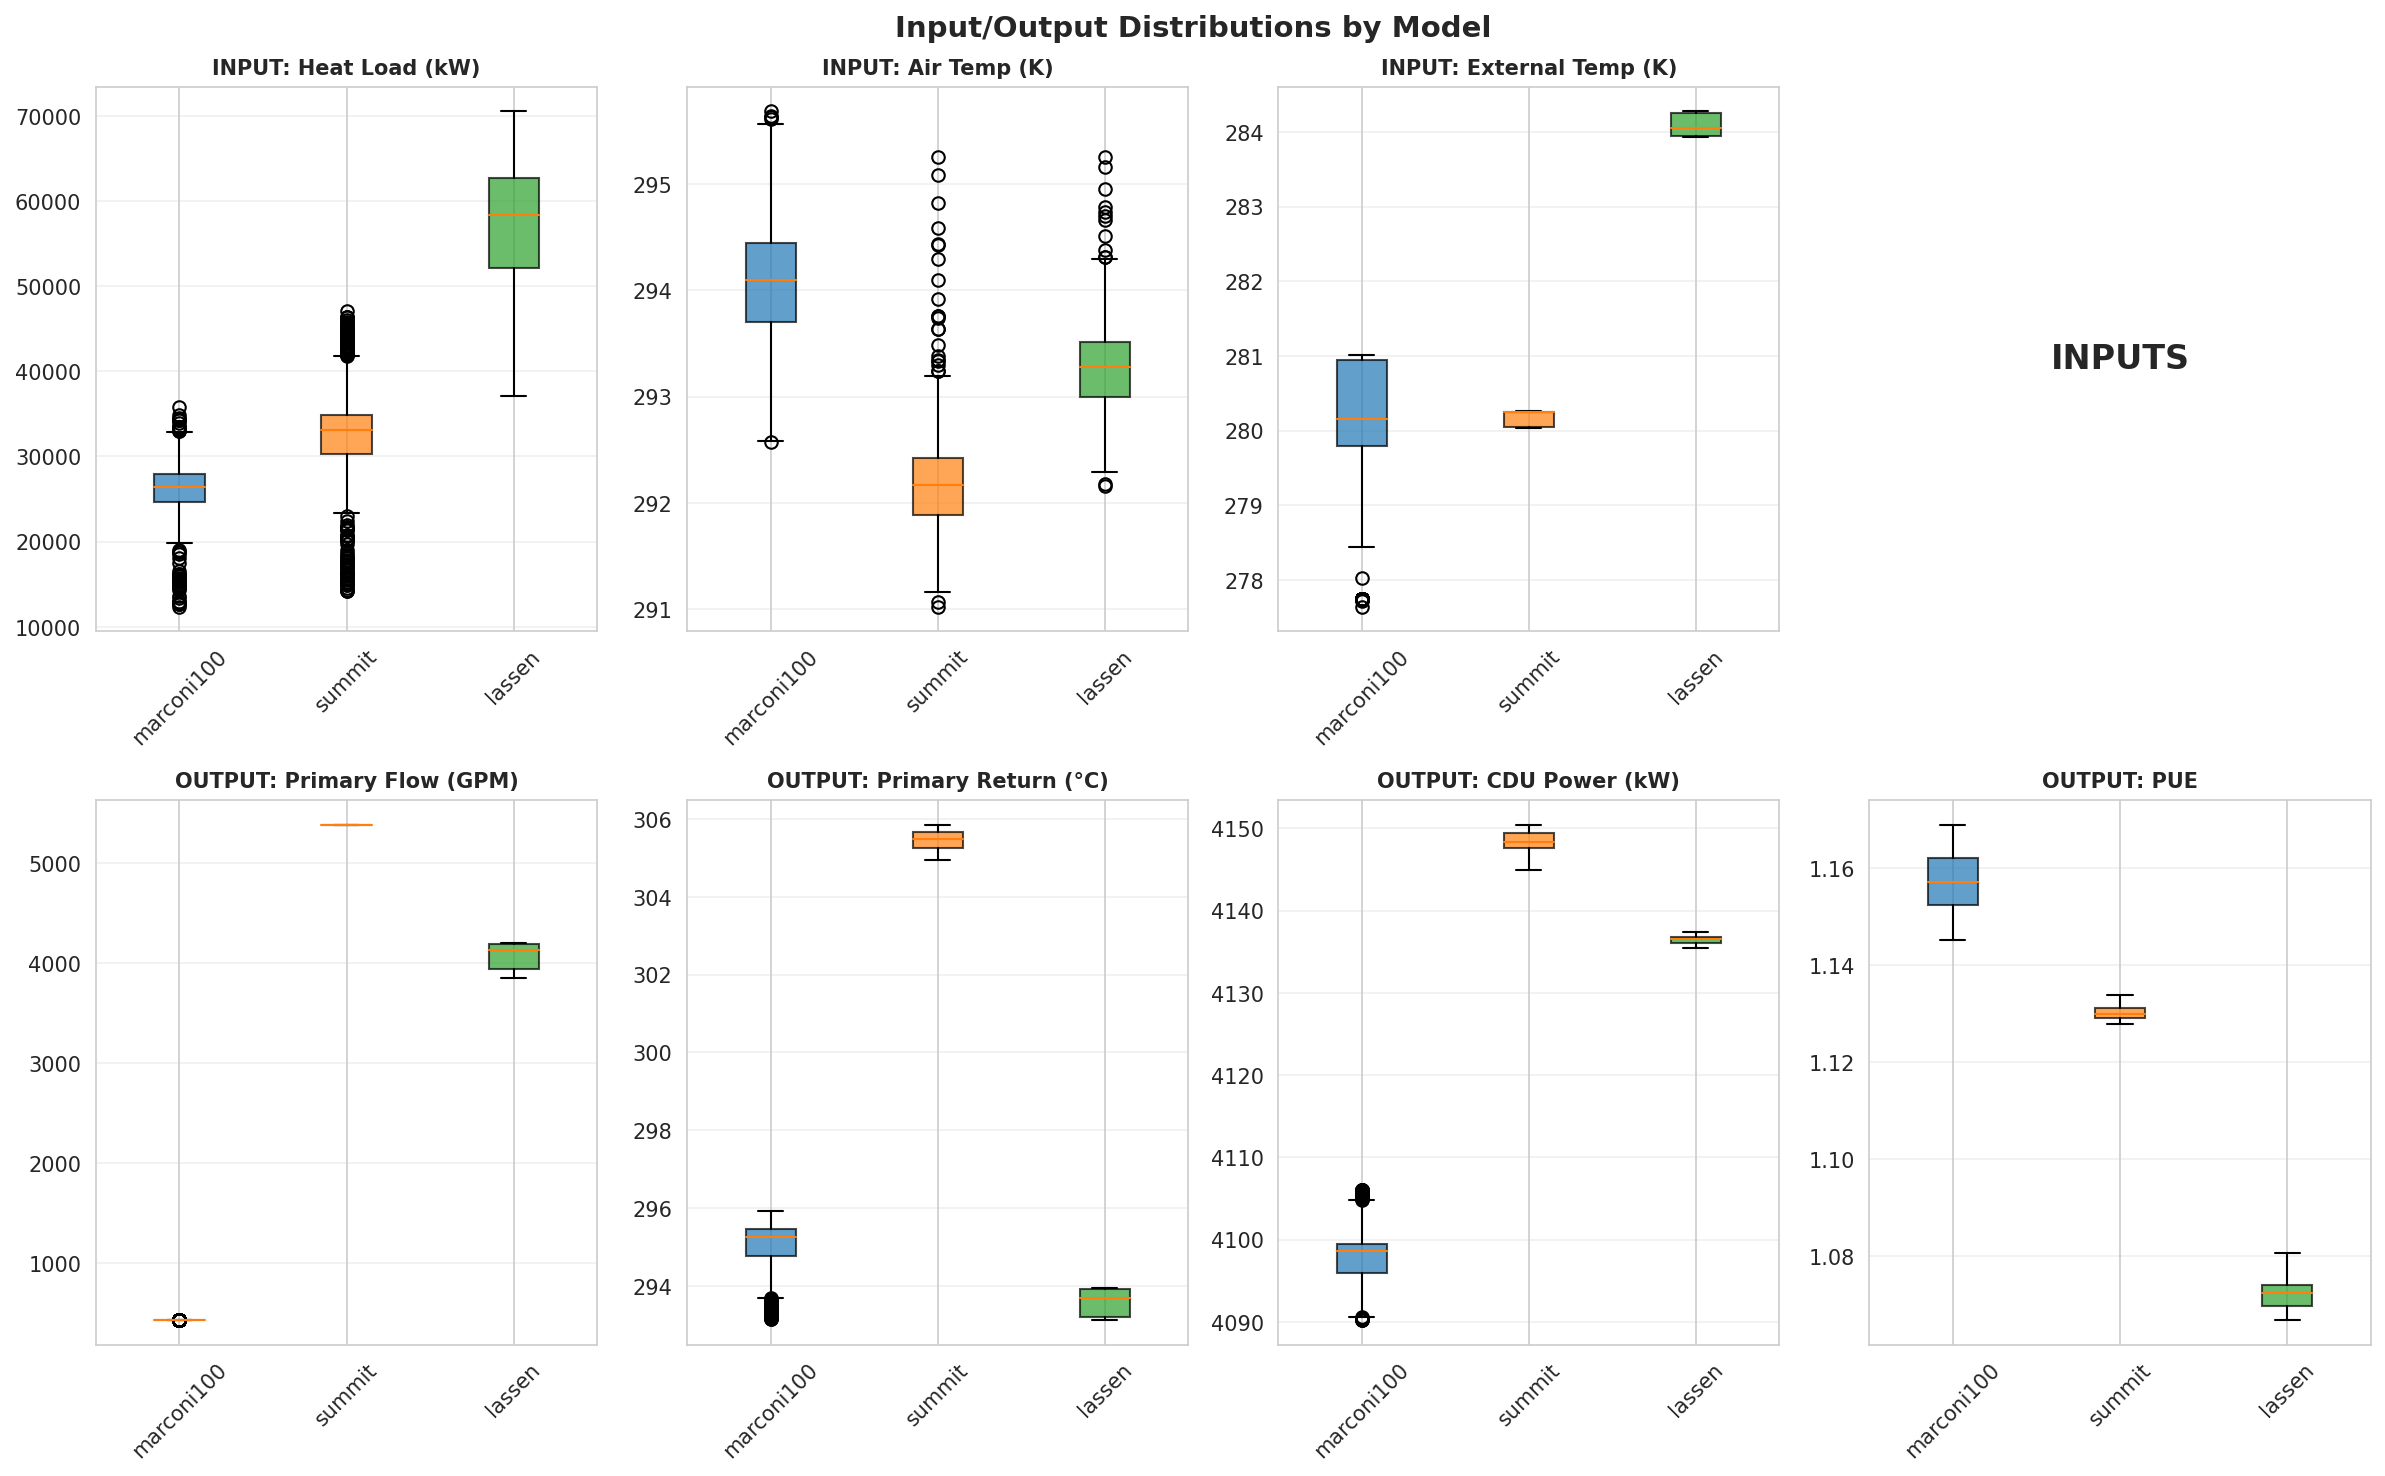


✓ Physics validation visualizations complete


In [14]:
# Visualize Physics Validation
from fmu2ml.analysis.comparative.visualizers import SimpleComparisonVisualizer

simple_viz = SimpleComparisonVisualizer(output_dir=PHYSICS_VALIDATION_DIR)

print("\n" + "="*80)
print("PHYSICS VALIDATION VISUALIZATIONS")
print("="*80)

# Physics validation summary
print("\n[1/3] Creating physics validation summary...")
fig = simple_viz.plot_physics_validation_summary(
    comparison,
    save_name='physics_validation_summary.png'
)
if fig:
    display(Image(filename=f'{PHYSICS_VALIDATION_DIR}/physics_validation_summary.png'))
    plt.close(fig)

# Physics metrics comparison
print("[2/3] Creating physics metrics comparison...")
fig = simple_viz.plot_physics_metrics_comparison(
    comparison,
    save_name='physics_metrics_comparison.png'
)
if fig:
    display(Image(filename=f'{PHYSICS_VALIDATION_DIR}/physics_metrics_comparison.png'))
    plt.close(fig)

# I/O distributions
print("[3/3] Creating I/O distributions...")
fig = simple_viz.plot_input_output_distributions(
    comparator.system_data,
    save_name='io_distributions.png'
)
if fig:
    display(Image(filename=f'{PHYSICS_VALIDATION_DIR}/io_distributions.png'))
    plt.close(fig)

print("\n✓ Physics validation visualizations complete")

In [15]:
# CDU-Level Analysis - Initialize
print("\n" + "="*80)
print("CDU-LEVEL COMPARATIVE ANALYSIS")
print("="*80)

# Create analysis configuration
cdu_config = AnalysisConfig(
    models=SYSTEMS,
    cdu_ids=SPECIFIC_CDU_IDS,
    n_representative_cdus=N_REPRESENTATIVE_CDUS,
    generate_data=False,  # We already have data
    run_fmu_simulation=False,
    output_dir=CDU_LEVEL_DIR,
    n_workers=N_WORKERS
)

# Initialize CDU comparative analysis
cdu_analysis = CDUComparativeAnalysis(cdu_config)

print(f"Initialized CDU-level analysis:")
print(f"  Models: {cdu_config.models}")
print(f"  CDUs to analyze: {cdu_analysis.cdu_ids}")
print(f"  Output directory: {CDU_LEVEL_DIR}")

2026-01-21 11:52:57 - fmu2ml.analysis.comparative.analyzers.cdu_response_analyzer - INFO - CDUResponseAnalyzer initialized for marconi100 (49 CDUs)
2026-01-21 11:52:57 - fmu2ml.analysis.comparative.analyzers.cdu_response_analyzer - INFO - CDUResponseAnalyzer initialized for summit (257 CDUs)
2026-01-21 11:52:57 - fmu2ml.analysis.comparative.analyzers.cdu_response_analyzer - INFO - CDUResponseAnalyzer initialized for lassen (257 CDUs)
2026-01-21 11:52:57 - fmu2ml.analysis.comparative.runners.cdu_comparative_analysis - INFO - CDUComparativeAnalysis initialized
2026-01-21 11:52:57 - fmu2ml.analysis.comparative.runners.cdu_comparative_analysis - INFO -   Models: ['marconi100', 'summit', 'lassen']
2026-01-21 11:52:57 - fmu2ml.analysis.comparative.runners.cdu_comparative_analysis - INFO -   CDUs: [1, 65, 129, 193, 257]
2026-01-21 11:52:57 - fmu2ml.analysis.comparative.runners.cdu_comparative_analysis - INFO -   Output: ../results/comparative_analysis/cdu_level/run_20260121_115257



CDU-LEVEL COMPARATIVE ANALYSIS
Initialized CDU-level analysis:
  Models: ['marconi100', 'summit', 'lassen']
  CDUs to analyze: [1, 65, 129, 193, 257]
  Output directory: ../results/comparative_analysis/cdu_level


In [16]:
# CDU Response Analysis
print("\n" + "="*80)
print("CDU RESPONSE CHARACTERIZATION")
print("="*80)

cdu_response_results = {}

for system_name in SYSTEMS:
    print(f"\nAnalyzing {system_name}...")
    analyzer = CDUResponseAnalyzer(system_name)
    data = comparator.system_data[system_name]
    
    # Analyze first CDU in detail
    cdu_id = cdu_analysis.cdu_ids[0]
    
    print(f"  Computing statistics for CDU {cdu_id}...")
    stats = analyzer.compute_response_statistics(data, cdu_id)
    
    print(f"  Computing correlations...")
    correlations = analyzer.compute_io_correlations(data, cdu_id)
    
    print(f"  Computing static gains...")
    gains = analyzer.compute_static_gains(data, cdu_id)
    
    print(f"  Computing nonlinearity indices...")
    nonlinearity = analyzer.compute_nonlinearity_index(data, cdu_id)
    
    cdu_response_results[system_name] = {
        'stats': stats,
        'correlations': correlations,
        'gains': gains,
        'nonlinearity': nonlinearity
    }
    
    # Save results
    correlations.to_csv(f'{CDU_LEVEL_DIR}/{system_name}_correlations_cdu{cdu_id}.csv', index=False)
    gains.to_csv(f'{CDU_LEVEL_DIR}/{system_name}_gains_cdu{cdu_id}.csv', index=False)
    nonlinearity.to_csv(f'{CDU_LEVEL_DIR}/{system_name}_nonlinearity_cdu{cdu_id}.csv', index=False)

print("\n✓ CDU response analysis complete")

2026-01-21 11:52:57 - fmu2ml.analysis.comparative.analyzers.cdu_response_analyzer - INFO - CDUResponseAnalyzer initialized for marconi100 (49 CDUs)



CDU RESPONSE CHARACTERIZATION

Analyzing marconi100...
  Computing statistics for CDU 1...
  Computing correlations...
  Computing static gains...
  Computing nonlinearity indices...


2026-01-21 11:52:57 - fmu2ml.analysis.comparative.analyzers.cdu_response_analyzer - INFO - CDUResponseAnalyzer initialized for summit (257 CDUs)



Analyzing summit...
  Computing statistics for CDU 1...
  Computing correlations...
  Computing static gains...
  Computing nonlinearity indices...


2026-01-21 11:52:57 - fmu2ml.analysis.comparative.analyzers.cdu_response_analyzer - INFO - CDUResponseAnalyzer initialized for lassen (257 CDUs)



Analyzing lassen...
  Computing statistics for CDU 1...
  Computing correlations...
  Computing static gains...
  Computing nonlinearity indices...

✓ CDU response analysis complete


In [17]:
# Display CDU Response Results
print("\n" + "="*80)
print("CDU RESPONSE ANALYSIS RESULTS")
print("="*80)

# Compare correlations
display(Markdown("### Input-Output Correlations"))
for system_name in SYSTEMS:
    display(Markdown(f"#### {system_name.upper()}"))
    corr_df = cdu_response_results[system_name]['correlations']
    significant = corr_df[corr_df['significant']].sort_values('correlation', ascending=False).head(10)
    display(significant[['input', 'output', 'correlation', 'p_value']])

# Compare static gains
display(Markdown("### Static Gains"))
for system_name in SYSTEMS:
    display(Markdown(f"#### {system_name.upper()}"))
    gains_df = cdu_response_results[system_name]['gains']
    top_gains = gains_df.sort_values('r2', ascending=False).head(10)
    display(top_gains[['input', 'output', 'gain', 'normalized_gain', 'r2', 'linear_fit_quality']])

# Compare nonlinearity
display(Markdown("### Nonlinearity Indices"))
for system_name in SYSTEMS:
    display(Markdown(f"#### {system_name.upper()}"))
    nonlin_df = cdu_response_results[system_name]['nonlinearity']
    nonlinear = nonlin_df[nonlin_df['relationship'] != 'linear'].sort_values('nonlinearity_index', ascending=False).head(10)
    display(nonlinear[['input', 'output', 'linear_r2', 'best_poly_degree', 'nonlinearity_index', 'relationship']])


CDU RESPONSE ANALYSIS RESULTS


### Input-Output Correlations

#### MARCONI100

,input,output,correlation,p_value
25,T_ext,T_prim_s_C,0.988158,0.0
29,T_ext,p_prim_s_psig,0.952818,0.0
30,T_ext,p_prim_r_psig,0.946319,0.0
10,Q_flow,p_sec_r_psig,0.863498,0.0
9,Q_flow,p_sec_s_psig,0.863481,0.0
26,T_ext,T_prim_r_C,0.807968,0.0
1,Q_flow,V_flow_sec_GPM,0.794825,0.0
24,T_ext,W_flow_CDUP_kW,0.630600,0.0
27,T_ext,T_sec_s_C,0.630513,0.0
28,T_ext,T_sec_r_C,0.627665,0.0


#### SUMMIT

...

,input,output,linear_r2,best_poly_degree,nonlinearity_index,relationship
29,T_ext,p_prim_s_psig,0.907862,3,0.123484,mildly_nonlinear
30,T_ext,p_prim_r_psig,0.895519,3,0.117959,mildly_nonlinear
26,T_ext,T_prim_r_C,0.652812,3,0.106729,mildly_nonlinear
22,T_ext,V_flow_prim_GPM,0.857792,3,0.103698,mildly_nonlinear


#### SUMMIT

,input,output,linear_r2,best_poly_degree,nonlinearity_index,relationship
30,T_ext,p_prim_r_psig,0.051401,3,0.624397,nonlinear
29,T_ext,p_prim_s_psig,0.052031,3,0.624391,nonlinear
25,T_ext,T_prim_s_C,0.631598,3,0.622631,nonlinear
22,T_ext,V_flow_prim_GPM,0.260643,3,0.594856,nonlinear
26,T_ext,T_prim_r_C,0.038108,3,0.565445,nonlinear
9,Q_flow,p_sec_s_psig,0.988930,3,0.296783,mildly_nonlinear
10,Q_flow,p_sec_r_psig,0.988928,3,0.296773,mildly_nonlinear
27,T_ext,T_sec_s_C,0.617221,3,0.295950,mildly_nonlinear
24,T_ext,W_flow_CDUP_kW,0.618123,3,0.293759,mildly_nonlinear
28,T_ext,T_sec_r_C,0.603487,3,0.291530,mildly_nonlinear


#### LASSEN

,input,output,linear_r2,best_poly_degree,nonlinearity_index,relationship
26,T_ext,T_prim_r_C,0.027629,3,0.715409,nonlinear
22,T_ext,V_flow_prim_GPM,0.489419,3,0.683121,nonlinear
30,T_ext,p_prim_r_psig,0.525759,3,0.619505,nonlinear
29,T_ext,p_prim_s_psig,0.419310,3,0.612469,nonlinear
25,T_ext,T_prim_s_C,0.864265,3,0.528086,nonlinear
7,Q_flow,p_prim_s_psig,0.309289,3,0.381979,nonlinear
8,Q_flow,p_prim_r_psig,0.292064,3,0.373028,nonlinear
0,Q_flow,V_flow_prim_GPM,0.156445,3,0.297867,mildly_nonlinear
9,Q_flow,p_sec_s_psig,0.883896,3,0.256554,mildly_nonlinear
10,Q_flow,p_sec_r_psig,0.883902,3,0.256551,mildly_nonlinear


In [18]:
# Sensitivity Analysis
print("\n" + "="*80)
print("SENSITIVITY ANALYSIS")
print("="*80)

from fmu2ml.analysis.comparative.analyzers import SensitivityConfig

sensitivity_config = SensitivityConfig(
    compute_sobol=True,
    n_samples_sobol=1024
)

sensitivity_analyzer = SensitivityAnalyzer(sensitivity_config)
sensitivity_results = {}

for system_name in SYSTEMS:
    print(f"\nAnalyzing {system_name}...")
    data = comparator.system_data[system_name]
    cdu_id = cdu_analysis.cdu_ids[0]
    
    print(f"  Computing sensitivity matrix for CDU {cdu_id}...")
    result = sensitivity_analyzer.analyze_cdu(data, cdu_id, system_name)
    sensitivity_results[system_name] = result
    
    print(f"  Mean sensitivity: {result.sensitivity_stats['jacobian_frobenius_norm']:.4f}")
    print(f"  Max sensitivity: {result.sensitivity_stats['max_sensitivity']:.4f}")
    print(f"  High-sensitivity regions: {result.sensitivity_stats['n_high_sensitivity_regions']}")

print("\n✓ Sensitivity analysis complete")

2026-01-21 11:52:58 - fmu2ml.analysis.comparative.analyzers.sensitivity_analyzer - INFO - Computing sensitivity matrix for CDU 1



SENSITIVITY ANALYSIS

Analyzing marconi100...
  Computing sensitivity matrix for CDU 1...


2026-01-21 11:52:59 - fmu2ml.analysis.comparative.analyzers.sensitivity_analyzer - INFO - Computing Sobol indices for CDU 1
2026-01-21 11:52:59 - fmu2ml.analysis.comparative.analyzers.sensitivity_analyzer - INFO - Identifying high-sensitivity regions for CDU 1
2026-01-21 11:53:01 - fmu2ml.analysis.comparative.analyzers.sensitivity_analyzer - INFO - Computing sensitivity matrix for CDU 1


  Mean sensitivity: 1.6057
  Max sensitivity: 0.8432
  High-sensitivity regions: 5

Analyzing summit...
  Computing sensitivity matrix for CDU 1...


2026-01-21 11:53:02 - fmu2ml.analysis.comparative.analyzers.sensitivity_analyzer - INFO - Computing Sobol indices for CDU 1
2026-01-21 11:53:02 - fmu2ml.analysis.comparative.analyzers.sensitivity_analyzer - INFO - Identifying high-sensitivity regions for CDU 1
2026-01-21 11:53:03 - fmu2ml.analysis.comparative.analyzers.sensitivity_analyzer - INFO - Computing sensitivity matrix for CDU 1


  Mean sensitivity: 0.5103
  Max sensitivity: 0.3458
  High-sensitivity regions: 5

Analyzing lassen...
  Computing sensitivity matrix for CDU 1...


2026-01-21 11:53:04 - fmu2ml.analysis.comparative.analyzers.sensitivity_analyzer - INFO - Computing Sobol indices for CDU 1
2026-01-21 11:53:05 - fmu2ml.analysis.comparative.analyzers.sensitivity_analyzer - INFO - Identifying high-sensitivity regions for CDU 1


  Mean sensitivity: 16.7925
  Max sensitivity: 16.3320
  High-sensitivity regions: 5

✓ Sensitivity analysis complete



SENSITIVITY VISUALIZATIONS

[marconi100] Creating sensitivity heatmap...


2026-01-21 11:53:07 - fmu2ml.analysis.comparative.visualizers.cdu_comparison_visualizer - INFO - Saved: ../results/comparative_analysis/cdu_level/sensitivity/sensitivity_heatmap_marconi100_cdu1.png


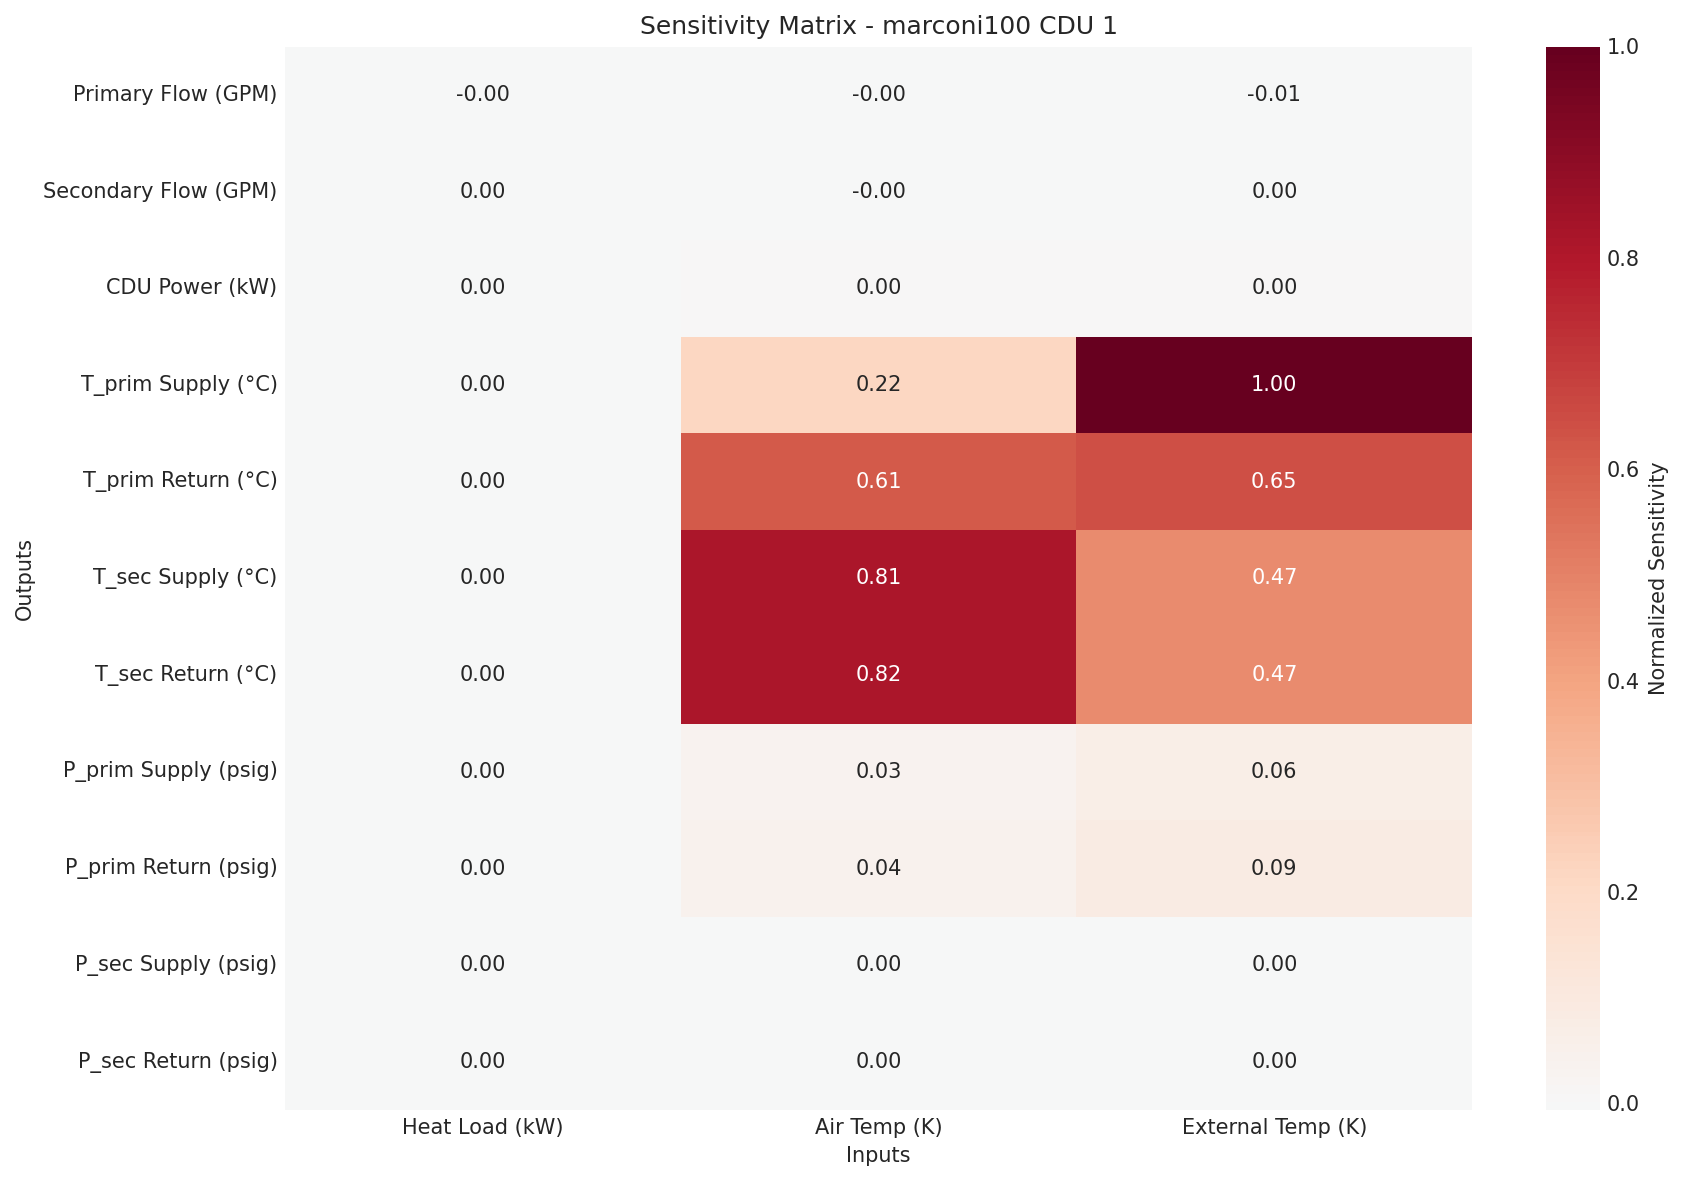


[summit] Creating sensitivity heatmap...


2026-01-21 11:53:07 - fmu2ml.analysis.comparative.visualizers.cdu_comparison_visualizer - INFO - Saved: ../results/comparative_analysis/cdu_level/sensitivity/sensitivity_heatmap_summit_cdu1.png


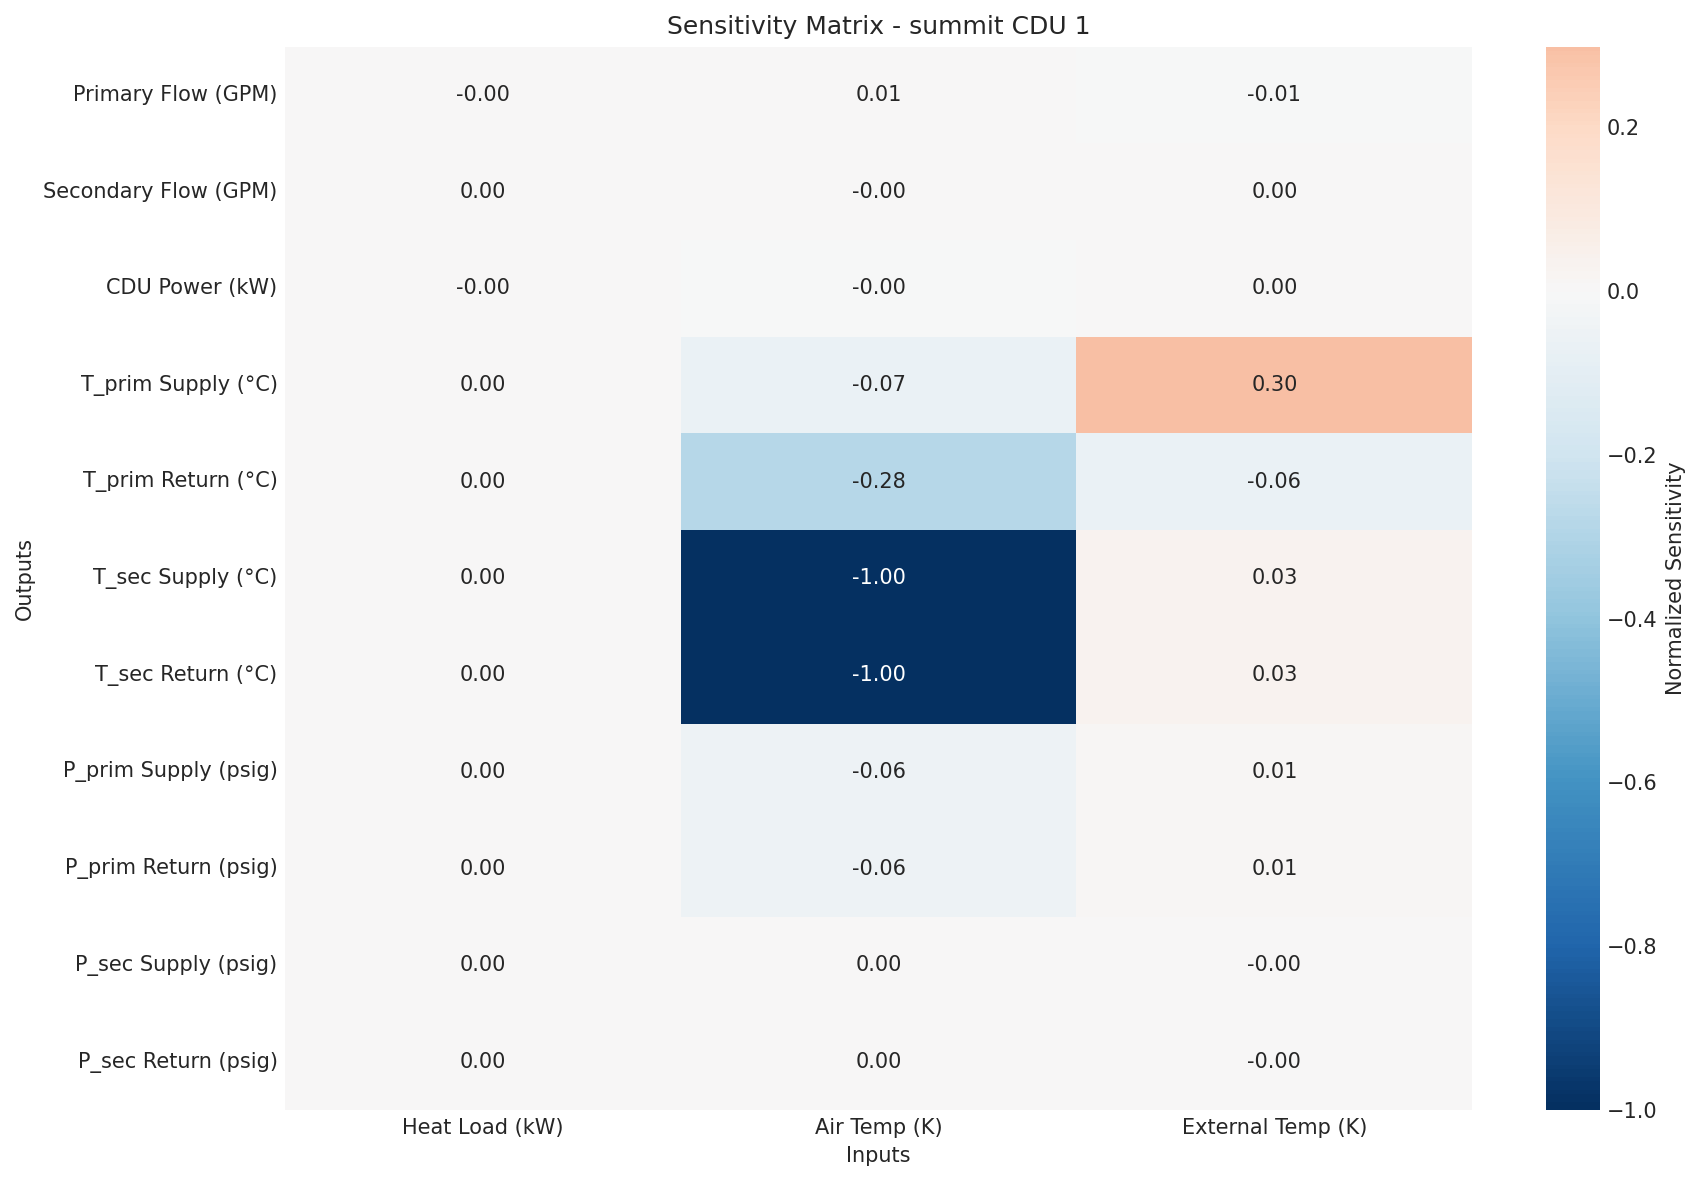


[lassen] Creating sensitivity heatmap...


2026-01-21 11:53:08 - fmu2ml.analysis.comparative.visualizers.cdu_comparison_visualizer - INFO - Saved: ../results/comparative_analysis/cdu_level/sensitivity/sensitivity_heatmap_lassen_cdu1.png


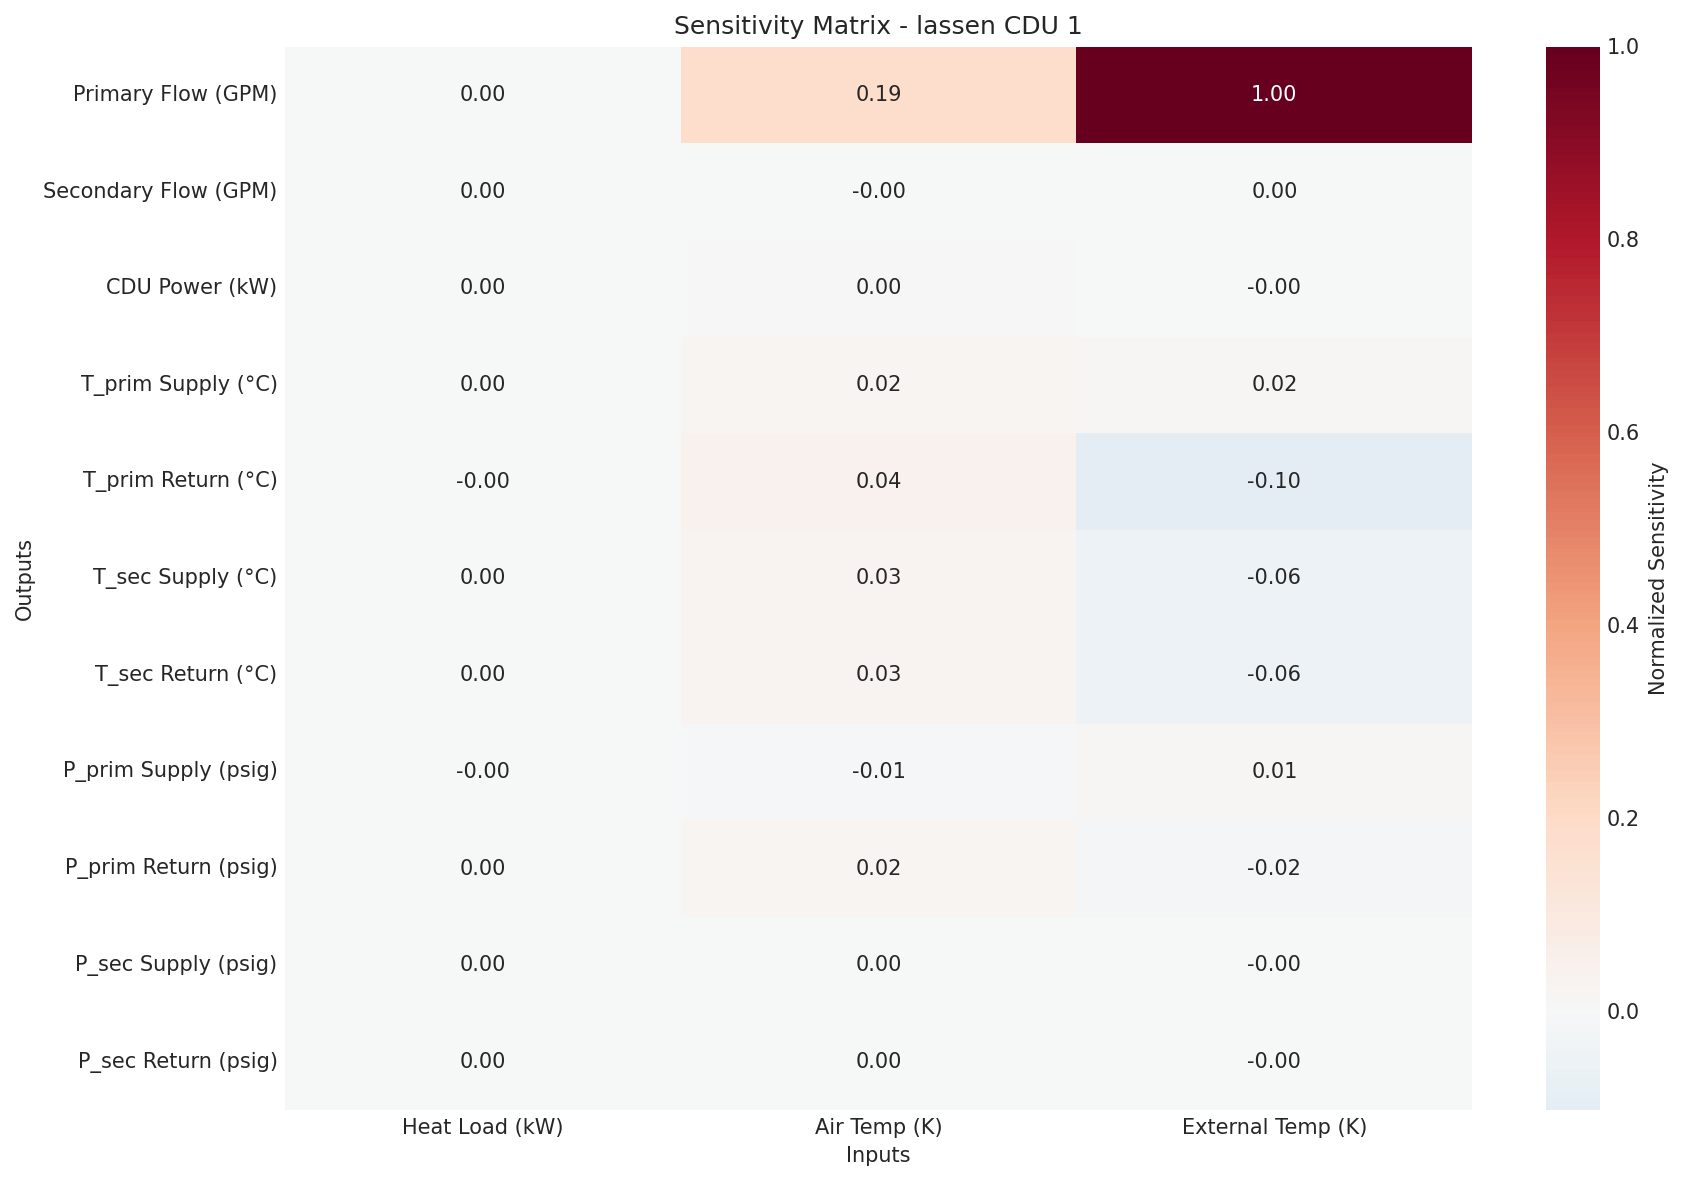


Creating sensitivity comparison...


2026-01-21 11:53:09 - fmu2ml.analysis.comparative.visualizers.cdu_comparison_visualizer - INFO - Saved: ../results/comparative_analysis/cdu_level/sensitivity/sensitivity_comparison_cdu1.png


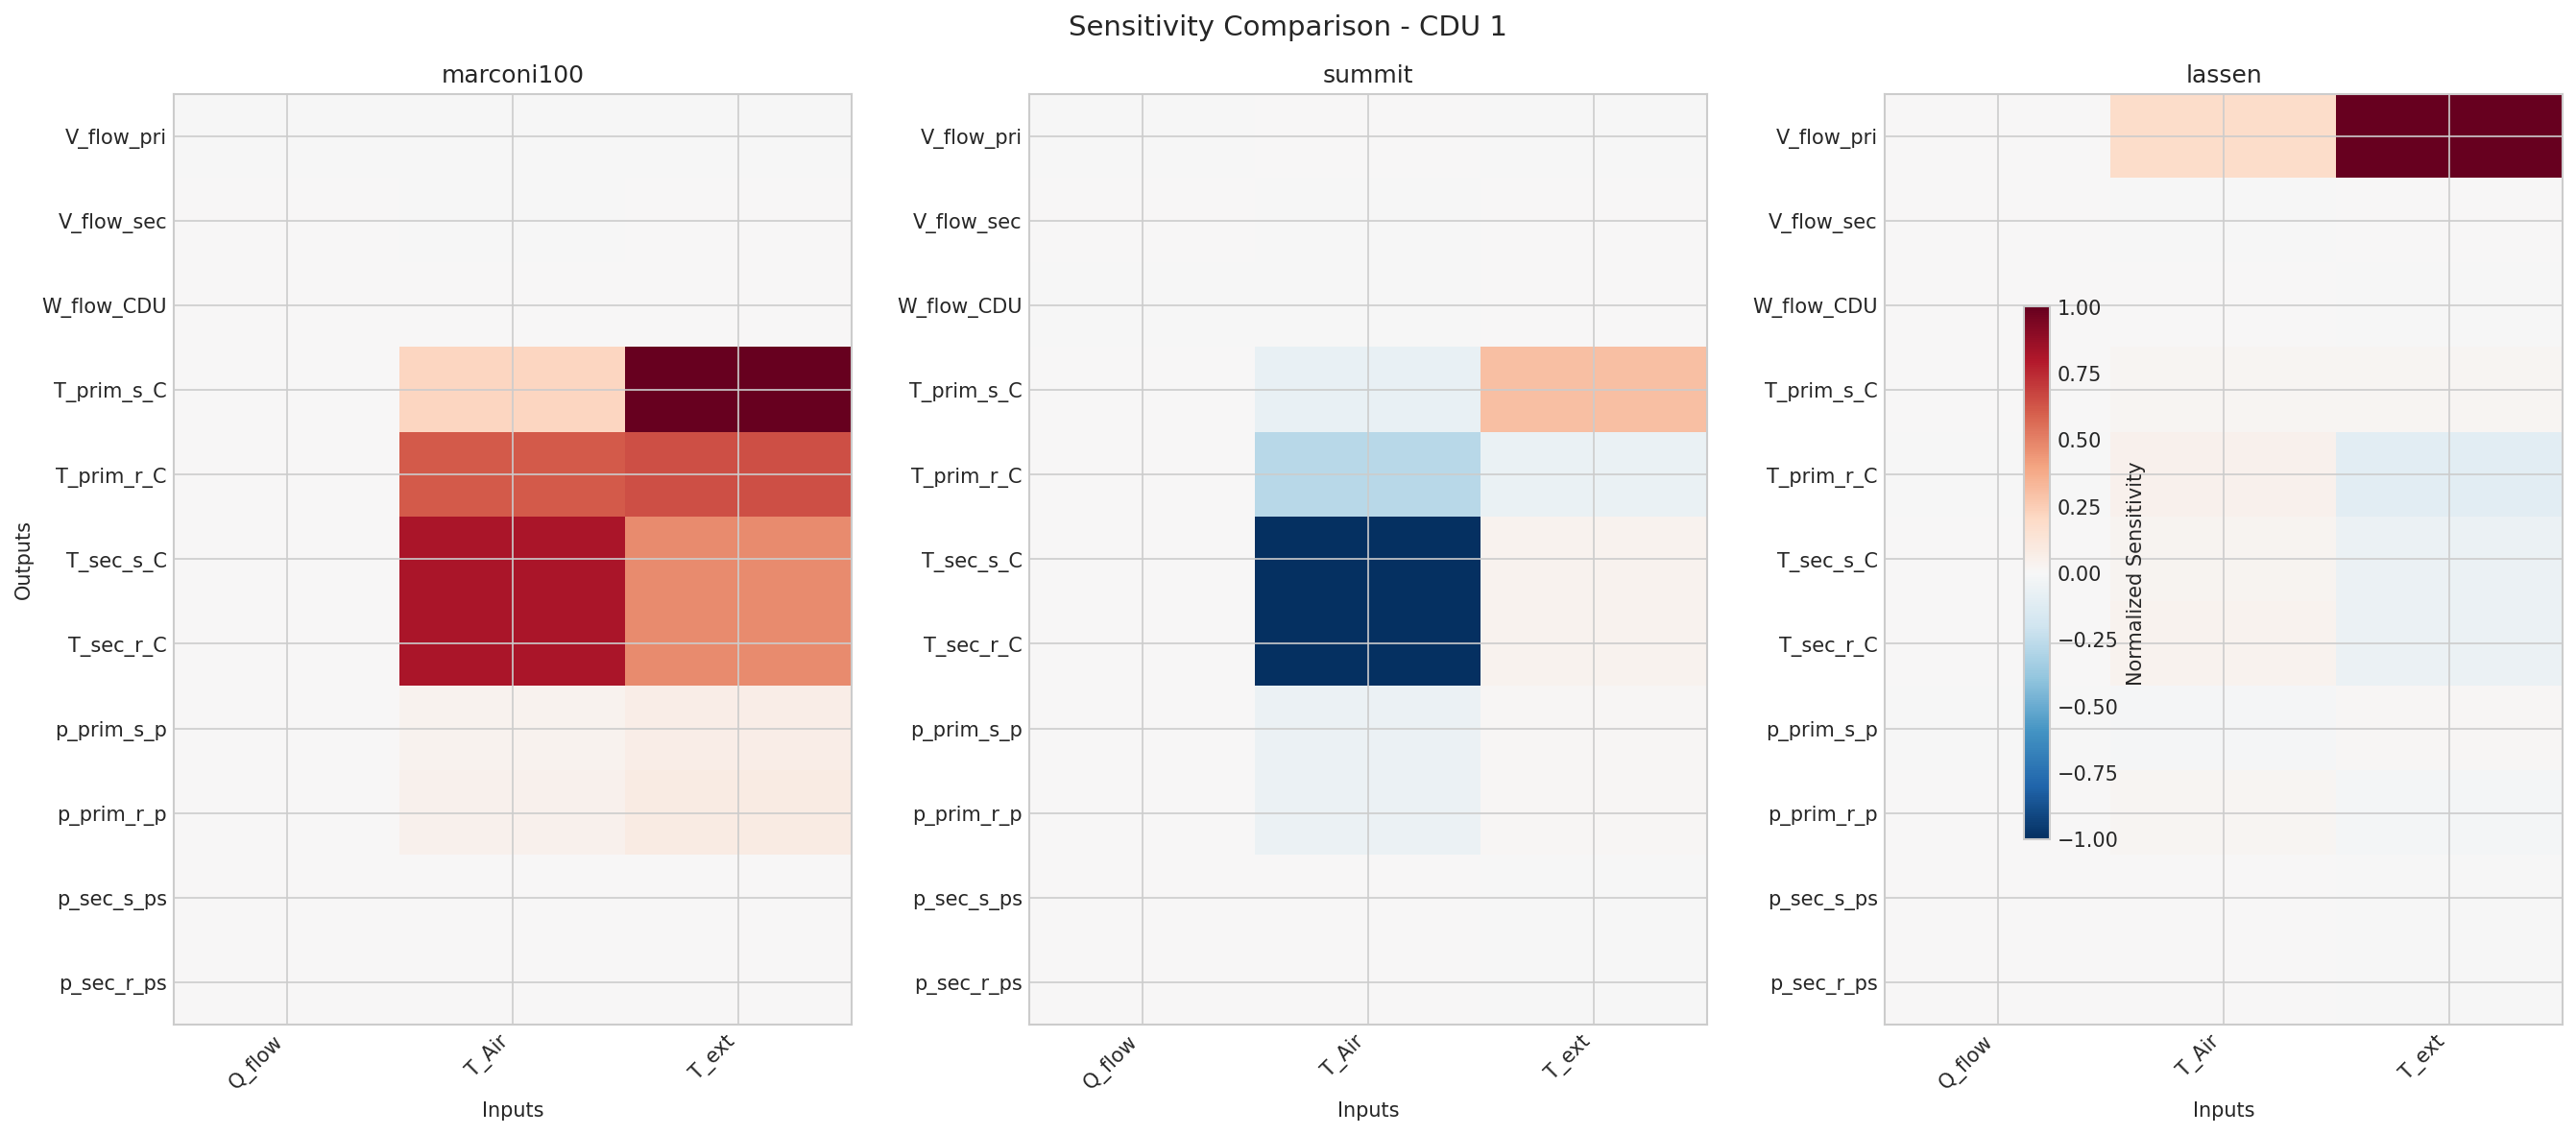


✓ Sensitivity visualizations complete


In [19]:
# Visualize Sensitivity Analysis
from fmu2ml.analysis.comparative.visualizers import CDUComparisonVisualizer

cdu_visualizer = CDUComparisonVisualizer(output_dir=f'{CDU_LEVEL_DIR}/sensitivity')

print("\n" + "="*80)
print("SENSITIVITY VISUALIZATIONS")
print("="*80)

cdu_id = cdu_analysis.cdu_ids[0]

# Individual sensitivity heatmaps
for system_name, result in sensitivity_results.items():
    print(f"\n[{system_name}] Creating sensitivity heatmap...")
    fig = cdu_visualizer.plot_sensitivity_heatmap(
        result.mean_sensitivity_matrix,
        system_name,
        cdu_id,
        save=True
    )
    if fig:
        img_path = f'{CDU_LEVEL_DIR}/sensitivity/sensitivity_heatmap_{system_name}_cdu{cdu_id}.png'
        display(Image(filename=img_path))
        plt.close(fig)

# Comparison across models
print("\nCreating sensitivity comparison...")
sensitivity_matrices = {
    name: result.mean_sensitivity_matrix
    for name, result in sensitivity_results.items()
}

fig = cdu_visualizer.plot_sensitivity_comparison(
    sensitivity_matrices,
    cdu_id,
    save=True
)
if fig:
    img_path = f'{CDU_LEVEL_DIR}/sensitivity/sensitivity_comparison_cdu{cdu_id}.png'
    display(Image(filename=img_path))
    plt.close(fig)

print("\n✓ Sensitivity visualizations complete")

In [20]:
# Dynamic Response Analysis (if step test data available)
print("\n" + "="*80)
print("DYNAMIC RESPONSE ANALYSIS")
print("="*80)

from fmu2ml.analysis.comparative.analyzers import DynamicConfig

dynamic_config = DynamicConfig(
    dt=1.0,
    compute_frequency_response=True
)

dynamic_analyzer = DynamicResponseAnalyzer(dynamic_config)
dynamic_results = {}

for system_name in SYSTEMS:
    print(f"\nAnalyzing {system_name}...")
    data = comparator.system_data[system_name]
    cdu_id = cdu_analysis.cdu_ids[0]
    
    print(f"  Analyzing dynamic response for CDU {cdu_id}...")
    try:
        result_dict = dynamic_analyzer.analyze_from_data(data, cdu_id, system_name)
        dynamic_results[system_name] = result_dict
        
        # Display time constants
        for input_var, outputs in result_dict.items():
            print(f"    {input_var}:")
            for output_var, result in outputs.items():
                if result.dominant_time_constant > 0:
                    print(f"      → {output_var}: τ = {result.dominant_time_constant:.2f}s")
    except Exception as e:
        print(f"  Warning: Dynamic analysis failed for {system_name}: {e}")

print("\n✓ Dynamic response analysis complete")


DYNAMIC RESPONSE ANALYSIS

Analyzing marconi100...
  Analyzing dynamic response for CDU 1...
    Q_flow:
      → V_flow_prim_GPM: τ = 103177.39s
      → V_flow_sec_GPM: τ = 146780.60s
      → W_flow_CDUP_kW: τ = 169355.12s
      → T_prim_s_C: τ = 170678.16s
      → T_prim_r_C: τ = 162771.94s
      → T_sec_s_C: τ = 167710.03s
      → T_sec_r_C: τ = 167686.69s
      → p_prim_s_psig: τ = 112113.89s
      → p_prim_r_psig: τ = 109522.74s
      → p_sec_s_psig: τ = 158492.33s
      → p_sec_r_psig: τ = 158497.14s
    T_Air:
      → V_flow_prim_GPM: τ = 103072.11s
      → V_flow_sec_GPM: τ = 283432.36s
      → W_flow_CDUP_kW: τ = 169050.98s
      → T_prim_s_C: τ = 170614.99s
      → T_prim_r_C: τ = 162461.69s
      → T_sec_s_C: τ = 167365.71s
      → T_sec_r_C: τ = 167529.11s
      → p_prim_s_psig: τ = 112017.62s
      → p_prim_r_psig: τ = 109422.97s
      → p_sec_s_psig: τ = 163166.09s
      → p_sec_r_psig: τ = 163171.60s
    T_ext:
      → V_flow_prim_GPM: τ = 138613.94s
      → V_flow_sec_G

In [21]:
# Transfer Function Analysis
print("\n" + "="*80)
print("TRANSFER FUNCTION ANALYSIS")
print("="*80)

from fmu2ml.analysis.comparative.analyzers import TransferFunctionConfig

tf_config = TransferFunctionConfig(
    compute_dc_gain=True,
    compute_coupling=True
)

tf_analyzer = TransferFunctionAnalyzer(tf_config)
tf_results = {}

for system_name in SYSTEMS:
    print(f"\nAnalyzing {system_name}...")
    data = comparator.system_data[system_name]
    cdu_id = cdu_analysis.cdu_ids[0]
    
    print(f"  Computing transfer functions for CDU {cdu_id}...")
    try:
        result = tf_analyzer.analyze_cdu(data, cdu_id, system_name)
        tf_results[system_name] = result
        
        print(f"  DC gain matrix shape: {result.dc_gain_matrix.shape if result.dc_gain_matrix is not None else 'N/A'}")
        if result.coupling_strength:
            print(f"  Coupling strength: {result.coupling_strength.get('diagonal_dominance', 'N/A'):.3f}")
    except Exception as e:
        print(f"  Warning: Transfer function analysis failed for {system_name}: {e}")

print("\n✓ Transfer function analysis complete")

2026-01-21 11:54:41 - fmu2ml.analysis.comparative.analyzers.transfer_function_analyzer - INFO - Computing DC gain matrix for CDU 1
2026-01-21 11:54:41 - fmu2ml.analysis.comparative.analyzers.transfer_function_analyzer - INFO - Identifying transfer functions for CDU 1



TRANSFER FUNCTION ANALYSIS

Analyzing marconi100...
  Computing transfer functions for CDU 1...


2026-01-21 11:54:43 - fmu2ml.analysis.comparative.analyzers.transfer_function_analyzer - INFO - Analyzing coupling for CDU 1
2026-01-21 11:54:43 - fmu2ml.analysis.comparative.analyzers.transfer_function_analyzer - INFO - Computing DC gain matrix for CDU 1
2026-01-21 11:54:43 - fmu2ml.analysis.comparative.analyzers.transfer_function_analyzer - INFO - Identifying transfer functions for CDU 1


  DC gain matrix shape: (11, 3)
  Coupling strength: 0.590

Analyzing summit...
  Computing transfer functions for CDU 1...


2026-01-21 11:54:44 - fmu2ml.analysis.comparative.analyzers.transfer_function_analyzer - INFO - Analyzing coupling for CDU 1
2026-01-21 11:54:44 - fmu2ml.analysis.comparative.analyzers.transfer_function_analyzer - INFO - Computing DC gain matrix for CDU 1
2026-01-21 11:54:44 - fmu2ml.analysis.comparative.analyzers.transfer_function_analyzer - INFO - Identifying transfer functions for CDU 1


  DC gain matrix shape: (11, 3)
  Coupling strength: 0.509

Analyzing lassen...
  Computing transfer functions for CDU 1...


2026-01-21 11:54:46 - fmu2ml.analysis.comparative.analyzers.transfer_function_analyzer - INFO - Analyzing coupling for CDU 1


  DC gain matrix shape: (11, 3)
  Coupling strength: 0.850

✓ Transfer function analysis complete


In [22]:
# Operating Regime Analysis
print("\n" + "="*80)
print("OPERATING REGIME ANALYSIS")
print("="*80)

from fmu2ml.analysis.comparative.analyzers import OperatingRegimeConfig

regime_config = OperatingRegimeConfig(
    compute_thermal_efficiency=True,
    compute_pumping_efficiency=True,
    compute_pue=True
)

regime_analyzer = OperatingRegimeAnalyzer(regime_config)
regime_results = {}

for system_name in SYSTEMS:
    print(f"\nAnalyzing {system_name}...")
    data = comparator.system_data[system_name]
    cdu_id = cdu_analysis.cdu_ids[0]
    
    print(f"  Computing operating regime for CDU {cdu_id}...")
    try:
        result = regime_analyzer.analyze_cdu(data, cdu_id, system_name)
        regime_results[system_name] = result
        
        # Display key metrics
        print(f"  Thermal efficiency: {result.thermal_efficiency.get('thermal_efficiency_prim_mean', 'N/A')}")
        print(f"  Pumping efficiency: {result.pumping_efficiency.get('pumping_efficiency_mean', 'N/A')}")
        print(f"  Operating envelope volume: {result.envelope_volume:.2f}")
        print(f"  Saturated outputs: {len(result.saturated_outputs)}")
    except Exception as e:
        print(f"  Warning: Operating regime analysis failed for {system_name}: {e}")

print("\n✓ Operating regime analysis complete")

2026-01-21 11:54:51 - fmu2ml.analysis.comparative.analyzers.operating_regime_analyzer - INFO - Analyzing operating regime for marconi100 CDU 1
2026-01-21 11:54:51 - fmu2ml.analysis.comparative.analyzers.operating_regime_analyzer - INFO - Analyzing operating regime for summit CDU 1
2026-01-21 11:54:51 - fmu2ml.analysis.comparative.analyzers.operating_regime_analyzer - INFO - Analyzing operating regime for lassen CDU 1



OPERATING REGIME ANALYSIS

Analyzing marconi100...
  Computing operating regime for CDU 1...
  Thermal efficiency: N/A
  Pumping efficiency: N/A
  Operating envelope volume: 58.39
  Saturated outputs: 8

Analyzing summit...
  Computing operating regime for CDU 1...
  Thermal efficiency: N/A
  Pumping efficiency: N/A
  Operating envelope volume: 48.07
  Saturated outputs: 9

Analyzing lassen...
  Computing operating regime for CDU 1...
  Thermal efficiency: N/A
  Pumping efficiency: N/A
  Operating envelope volume: 51.44
  Saturated outputs: 12

✓ Operating regime analysis complete


In [23]:
# Generate Comprehensive Report
print("\n" + "="*80)
print("GENERATING COMPREHENSIVE REPORT")
print("="*80)

from fmu2ml.analysis.comparative.visualizers import create_comprehensive_report

# Prepare comparison results dictionary
comparison_dict = {
    'efficiency': efficiency_df,
    'thermal': thermal_df,
    'flow': flow_df,
    'dynamic': dynamic_df,
    'normalized': normalized_df
}

# Create comprehensive report
report_paths = create_comprehensive_report(
    comparison_results=comparison_dict,
    system_metrics=system_metrics,
    output_dir=SYSTEM_COMPARISON_DIR,
    system_data=comparator.system_data,
    create_pdf=True
)

print("\n✓ Report generated:")
for report_type, path in report_paths.items():
    print(f"  {report_type}: {path}")

# Display PDF if created
if 'pdf_report' in report_paths:
    print("\n📊 PDF report created successfully!")
    print(f"   Location: {report_paths['pdf_report']}")

2026-01-21 11:54:52 - fmu2ml.analysis.comparative.visualizers.report_generator - INFO - Generating comprehensive report in ../results/comparative_analysis/system_comparison



GENERATING COMPREHENSIVE REPORT


2026-01-21 11:54:55 - fmu2ml.analysis.comparative.visualizers.comparison_charts - INFO - Saved efficiency comparison to ../results/comparative_analysis/system_comparison/01_efficiency_comparison_20260121_115452.png
2026-01-21 11:54:57 - fmu2ml.analysis.comparative.visualizers.thermal_visualizer - INFO - Saved thermal comparison to ../results/comparative_analysis/system_comparison/02_thermal_comparison_20260121_115452.png
2026-01-21 11:54:59 - fmu2ml.analysis.comparative.visualizers.power_visualizer - INFO - Saved power profile comparison to ../results/comparative_analysis/system_comparison/03_power_profile_20260121_115452.png
2026-01-21 11:55:00 - fmu2ml.analysis.comparative.visualizers.scaling_visualizer - INFO - Saved scaling analysis to ../results/comparative_analysis/system_comparison/04_scaling_analysis_20260121_115452.png
2026-01-21 11:55:01 - fmu2ml.analysis.comparative.visualizers.comparison_charts - INFO - Saved radar chart to ../results/comparative_analysis/system_comparison/


✓ Report generated:
  efficiency: ../results/comparative_analysis/system_comparison/01_efficiency_comparison_20260121_115452.png
  thermal: ../results/comparative_analysis/system_comparison/02_thermal_comparison_20260121_115452.png
  power_profile: ../results/comparative_analysis/system_comparison/03_power_profile_20260121_115452.png
  scaling: ../results/comparative_analysis/system_comparison/04_scaling_analysis_20260121_115452.png
  radar: ../results/comparative_analysis/system_comparison/05_radar_comparison_20260121_115452.png
  flow: ../results/comparative_analysis/system_comparison/06_flow_comparison_20260121_115452.png
  dynamic: ../results/comparative_analysis/system_comparison/07_dynamic_comparison_20260121_115452.png
  pdf_report: ../results/comparative_analysis/system_comparison/cooling_model_comparison_report_20260121_115452.pdf
  summary: ../results/comparative_analysis/system_comparison/comparison_summary_20260121_115452.txt

📊 PDF report created successfully!
   Location

In [24]:
#  Generate Summary Text Report
print("\n" + "="*80)
print("SUMMARY REPORT")
print("="*80)

summary = comparator.generate_summary_report()
display(Markdown(f"```\n{summary}\n```"))

# Save summary
with open(f'{OUTPUT_DIR_BASE}/summary_report.txt', 'w') as f:
    f.write(summary)

print(f"\n✓ Summary saved to {OUTPUT_DIR_BASE}/summary_report.txt")


SUMMARY REPORT


```
================================================================================
COOLING MODEL COMPARISON SUMMARY REPORT
================================================================================
Generated: 2026-01-21 11:55:05
Systems Compared: marconi100, summit, lassen

SYSTEM OVERVIEW
----------------------------------------
  marconi100:
    - CDUs: 49
    - Nodes/Rack: 20
    - GPUs/Node: 4
    - Cooling Efficiency: 0.945
  summit:
    - CDUs: 257
    - Nodes/Rack: 18
    - GPUs/Node: 6
    - Cooling Efficiency: 0.945
  lassen:
    - CDUs: 257
    - Nodes/Rack: 18
    - GPUs/Node: 4
    - Cooling Efficiency: 0.945

EFFICIENCY COMPARISON
----------------------------------------
  marconi100:
    - Mean CDUP Power: 200.56 kW
    - Cooling Power Ratio: 0.0002
  summit:
    - Mean CDUP Power: 1066.88 kW
    - Cooling Power Ratio: 0.0001
  lassen:
    - Mean CDUP Power: 182.10 kW
    - Cooling Power Ratio: 0.0001

THERMAL PERFORMANCE
----------------------------------------
  marconi100:
    - Mean Return Temp: 31.06 °C
    - Mean ΔT: 0.26 °C
  summit:
    - Mean Return Temp: 43.85 °C
    - Mean ΔT: 0.30 °C
  lassen:
    - Mean Return Temp: 41.36 °C
    - Mean ΔT: 0.54 °C

NORMALIZED COMPARISON (Per-CDU Metrics)
----------------------------------------
  marconi100:
    - CDUP Power/CDU: 4.09 kW
    - Flow/CDU: 317.46 GPM
  summit:
    - CDUP Power/CDU: 4.15 kW
    - Flow/CDU: 317.46 GPM
  lassen:
    - CDUP Power/CDU: 0.71 kW
    - Flow/CDU: 54.35 GPM

================================================================================
```


✓ Summary saved to ../results/comparative_analysis/summary_report.txt


In [25]:
# Analysis Summary Statistics
print("\n" + "="*80)
print("ANALYSIS SUMMARY STATISTICS")
print("="*80)

summary_stats = {
    'systems_analyzed': len(SYSTEMS),
    'total_samples': sum(len(comparator.system_data[s]) for s in SYSTEMS),
    'cdus_analyzed': len(cdu_analysis.cdu_ids),
    'analyses_completed': []
}

if sensitivity_results:
    summary_stats['analyses_completed'].append('Sensitivity Analysis')
if dynamic_results:
    summary_stats['analyses_completed'].append('Dynamic Response Analysis')
if tf_results:
    summary_stats['analyses_completed'].append('Transfer Function Analysis')
if regime_results:
    summary_stats['analyses_completed'].append('Operating Regime Analysis')

display(Markdown("### Analysis Summary"))
for key, value in summary_stats.items():
    if isinstance(value, list):
        print(f"**{key.replace('_', ' ').title()}:**")
        for item in value:
            print(f"  - {item}")
    else:
        print(f"**{key.replace('_', ' ').title()}:** {value}")

print("\n" + "="*80)
print("COMPARATIVE ANALYSIS COMPLETE")
print("="*80)


ANALYSIS SUMMARY STATISTICS


### Analysis Summary

**Systems Analyzed:** 3
**Total Samples:** 10800
**Cdus Analyzed:** 5
**Analyses Completed:**
  - Sensitivity Analysis
  - Dynamic Response Analysis
  - Transfer Function Analysis
  - Operating Regime Analysis

COMPARATIVE ANALYSIS COMPLETE
